# Lecture 4: Bayesian Workflow
## Contents
- [4.1 Bayesian workflow](#section-41)
- [4.2 Sampling challenges](#section-42)
- [4.3 Monte-Carlo Markov Chain](#section-43)
- [4.4 Metropolis](#section-44)
- [4.5 Sampling diagnostics](#section-45)
- [4.6 HMC and NUTS](#section-46)
- [4.7 Divergences](#section-47)
- [4.8 PyTensor](#section-48)
- [4.9 Workflow validation](#section-49)

This notebook is a first-pass structural alignment to the current Lecture 4 slide deck. It reorders existing material into lecture order, pulls in matching content from other lecture notebooks, and marks the places where slide-specific material still needs to be generated later.


## Setup


### Data access policy
This notebook is designed to run cleanly in Colab without requiring students to clone the full course repository. Lecture 4 uses remote course data files for the Gaussian workflow examples, and the setup cell below upgrades Bayesian-analysis packages in Colab only when the runtime is older than the versions expected by this notebook.


In [67]:
import importlib.metadata
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules
MIN_PACKAGE_VERSIONS = {
    "pymc": "5.25.1",
    "arviz": "0.23.4",
    "arviz-stats": "0.8.0",
    "preliz": "0.24.0",
}

def ensure_colab_packages(package_min_versions):
    if not IS_COLAB:
        return

    from importlib.metadata import PackageNotFoundError, version
    from packaging.version import Version

    packages_to_install = []
    for package_name, min_version in package_min_versions.items():
        try:
            current_version = version(package_name)
        except PackageNotFoundError:
            current_version = None
        if current_version is None or Version(current_version) < Version(min_version):
            packages_to_install.append(f"{package_name}>={min_version}")

    if packages_to_install:
        print("Upgrading Colab packages:", ", ".join(packages_to_install))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages_to_install])
        print("Upgrade complete. If imports fail, restart the runtime and run all cells again.")
    else:
        print("Colab runtime already satisfies the notebook package requirements.")

ensure_colab_packages(MIN_PACKAGE_VERSIONS)


### Required data files


In [68]:
REQUIRED_DATA_FILES = []


### Resolve required data files


In [69]:
DATA_FILE_PATHS = {}


### Do imports and settings


In [70]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor
import scipy.stats as stats


In [71]:
rng = np.random.default_rng(123)
az.style.use("arviz-whitegrid")
plt.rcParams["figure.dpi"] = 150


<a id="section-41"></a>
## 4.1 Bayesian workflow
### The main path and the three checks
The current slide deck opens with the full Bayesian workflow and emphasizes three distinct tests: model coherence, sampling validity, and posterior predictive fit. 

<a id="section-42"></a>
## 4.2 Sampling challenges
### Sampling arbitrary densities
Slides 6-12 introduce the motivation for sampling, rejection sampling, and the idea of `pm.sample()` as a black box. This section now starts with the conjugate beta-binomial shortcut from Lecture 3, then adds a simple non-beta prior example before leaving placeholders for the later non-conjugate sampling material that still needs to be generated.


### Conjugate posterior shortcut

The updated slide 7 now makes the contrast explicit: for the beta-binomial model from Lecture 3, a conjugate prior gives a closed-form posterior, so we can sample from that posterior directly instead of introducing more general sampling machinery yet.



We reuse the Lecture 3 data-generating example and a $\mathrm{Beta}(1, 1)$ prior. For Bernoulli observations, the posterior is



$$

\theta \mid y \sim \mathrm{Beta}\left(\alpha + \sum y_i,\; \beta + n - \sum y_i\right).

$$



With $\alpha = \beta = 1$ and the observed sample below, this becomes a concrete beta posterior that we can sample directly with Preliz.


C:\Users\User\AppData\Local\Temp\ipykernel_33728\2460571297.py:36: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


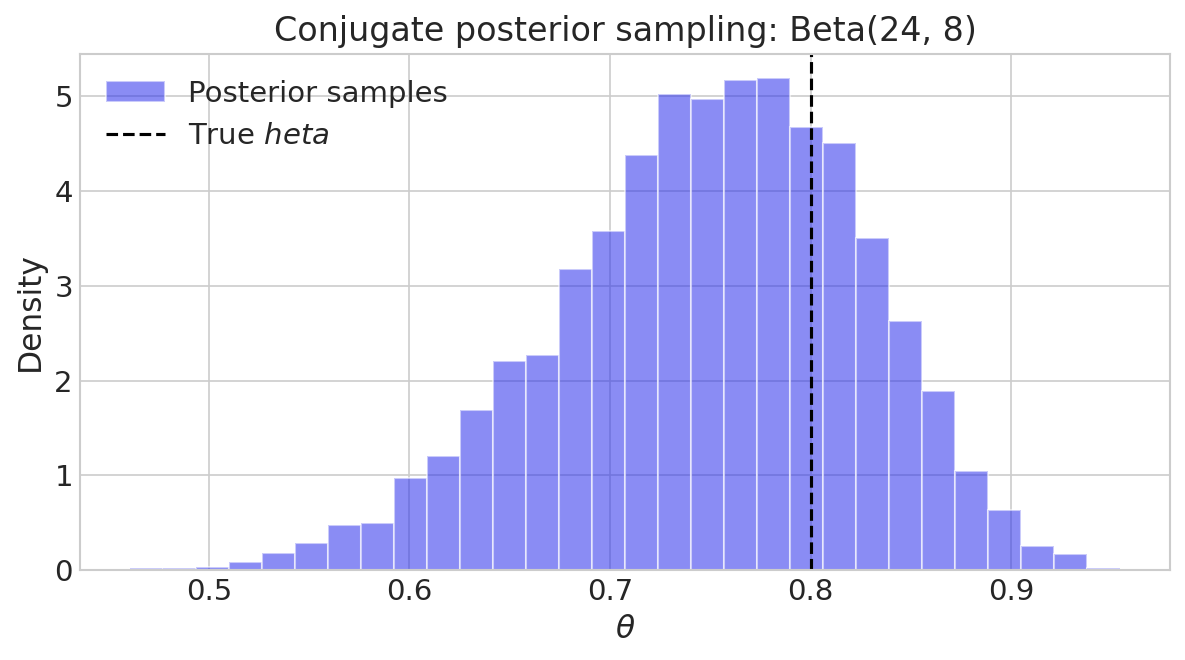

{'successes': 23, 'failures': 7, 'posterior': 'Beta(24, 8)'}

In [72]:
np.random.seed(123)
sample_size = 30
theta_real = 0.8  # simulated data-generating value used throughout the notebook
bernoulli_data = pz.Binomial(n=1, p=theta_real).rvs(sample_size, random_state=123)

with pm.Model() as our_first_model:
    theta = pm.Beta('theta', alpha=1., beta=1.)
    y = pm.Bernoulli('y', p=theta, observed=bernoulli_data)

alpha_prior = 1
beta_prior = 1
successes = int(np.sum(bernoulli_data))
failures = sample_size - successes
alpha_post = alpha_prior + successes
beta_post = beta_prior + failures

posterior_dist = pz.Beta(alpha=alpha_post, beta=beta_post)
posterior_samples = posterior_dist.rvs(5_000, random_state=123)


fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(
    posterior_samples,
    bins=30,
    density=True,
    alpha=0.55,
    color='C0',
    edgecolor='white',
    label='Posterior samples',
)
ax.axvline(theta_real, color='black', linestyle='--', linewidth=1.5, label='True $\theta$')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Density')
ax.set_title(f'Conjugate posterior sampling: Beta({alpha_post}, {beta_post})')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

{
    'successes': successes,
    'failures': failures,
    'posterior': f'Beta({alpha_post}, {beta_post})',
}

### A simple non-beta prior in PyMC

To motivate the need for more general samplers, we can keep the same binomial likelihood but replace the beta prior with a truncated normal prior. This version keeps the code minimal so the prior shape can be tuned quickly.

C:\Users\User\AppData\Local\Temp\ipykernel_33728\3854261906.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


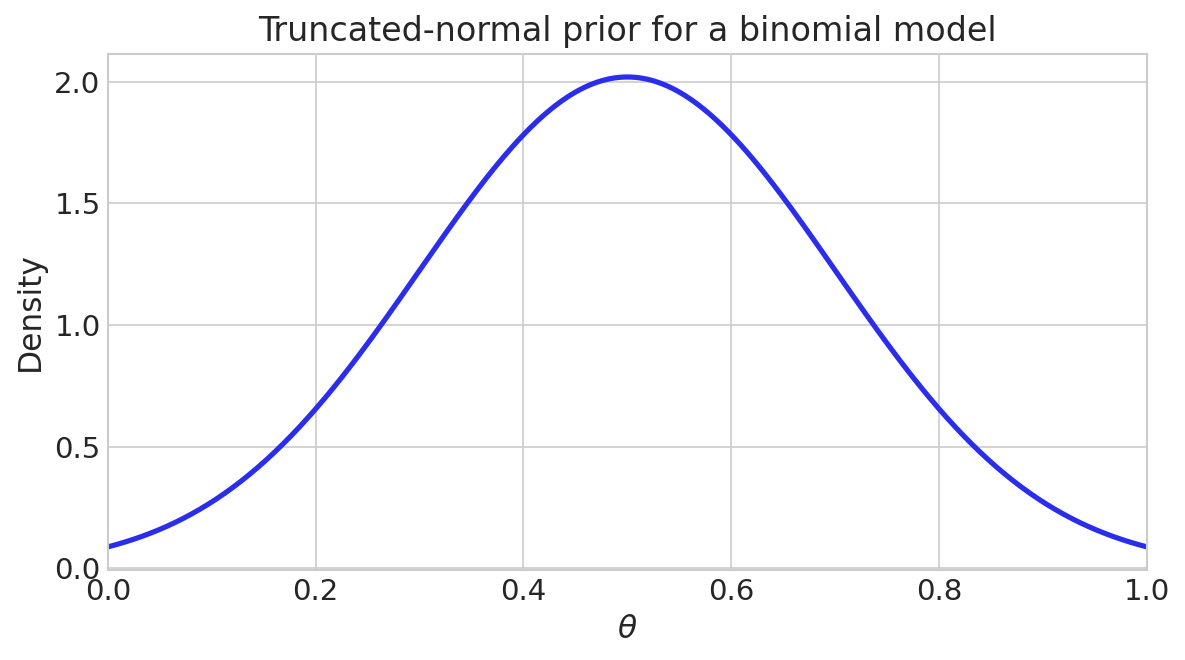

{'sigma': 0.2, 'endpoint_to_mode_ratio': np.float64(0.043936933623407455)}

In [73]:
theta_prior_mu = 0.5
theta_prior_sigma = 0.2
lower = 0.0
upper = 1.0

a = (lower - theta_prior_mu) / theta_prior_sigma
b = (upper - theta_prior_mu) / theta_prior_sigma
truncnorm_prior = stats.truncnorm(a=a, b=b, loc=theta_prior_mu, scale=theta_prior_sigma)

theta_grid = np.linspace(lower, upper, 500)
prior_pdf = truncnorm_prior.pdf(theta_grid)
endpoint_ratio = truncnorm_prior.pdf(lower) / truncnorm_prior.pdf(theta_prior_mu)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_grid, prior_pdf, color='C0', linewidth=2.5)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Density')
ax.set_title('Truncated-normal prior for a binomial model')
ax.set_xlim(lower, upper)
fig.tight_layout()
plt.show()

{
    'sigma': theta_prior_sigma,
    'endpoint_to_mode_ratio': endpoint_ratio,
}


### A non-conjugate binomial model in PyMC
Now we can write the same binomial likelihood with the truncated-normal prior directly in PyMC. This is the same data as above, but the prior is no longer beta, so we should not expect a beta posterior in closed form.


In [74]:
with pm.Model() as nonconjugate_binomial_model:
    theta_nonbeta = pm.TruncatedNormal(
        'theta',
        mu=theta_prior_mu,
        sigma=theta_prior_sigma,
        lower=lower,
        upper=upper,
    )
    y_nonbeta = pm.Bernoulli('y', p=theta_nonbeta, observed=bernoulli_data)

### Posterior for the truncated-normal prior
For this model,

$$
p(\theta \mid y) = \frac{p(y \mid \theta)\,p(\theta)}{\mathrm{Evidence}}.
$$

Here the likelihood comes from the Bernoulli observations and the prior is the truncated normal on $[0, 1]$. Writing the Bernoulli sample in terms of the number of successes $s = \sum_i y_i$ and failures $f = n-s$, the posterior is

$$
p(\theta \mid y) = \frac{C\,\theta^{s}(1-\theta)^{f}\exp\!\left(-\frac{(\theta-\mu)^2}{2\sigma^2}\right)}{\mathrm{Evidence}}, \qquad 0 \le \theta \le 1,
$$

Because the prior is not beta, we will approximate this posterior on a grid and plot the normalized result.


C:\Users\User\AppData\Local\Temp\ipykernel_33728\1498964473.py:16: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


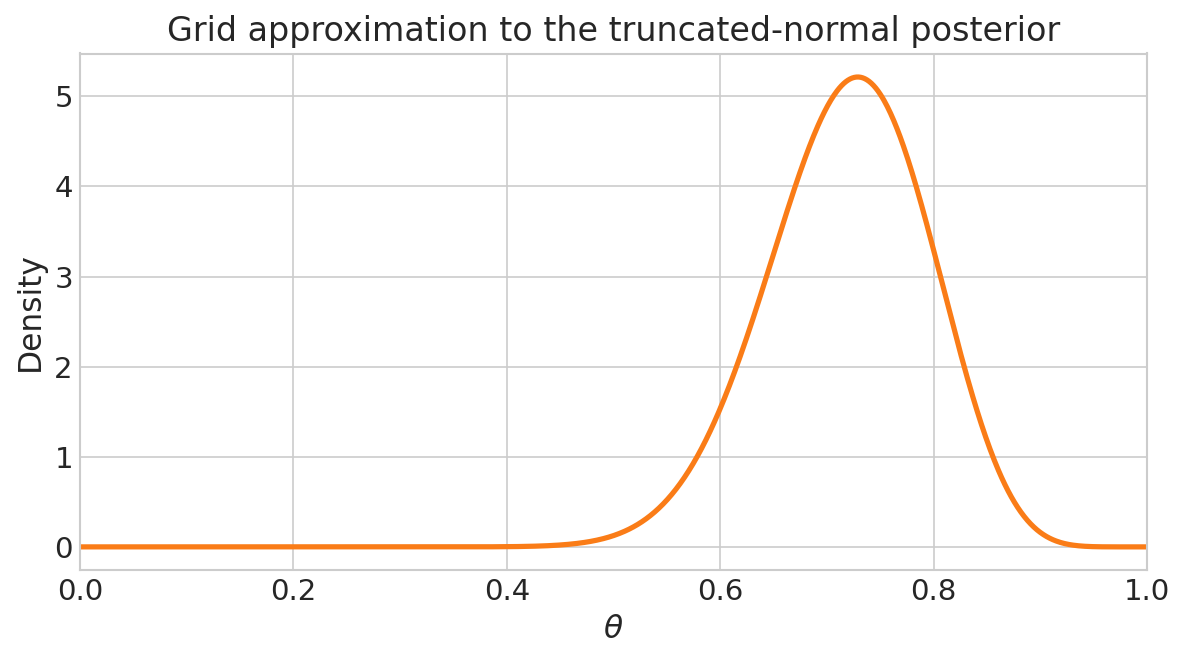

{'successes': 23, 'failures': 7}

In [75]:
successes_nonbeta = int(np.sum(bernoulli_data))
failures_nonbeta = sample_size - successes_nonbeta

theta_grid = np.linspace(lower + 1e-6, upper - 1e-6, 1000)
prior_pdf_grid = truncnorm_prior.pdf(theta_grid)
likelihood_grid = theta_grid**successes_nonbeta * (1 - theta_grid)**failures_nonbeta
posterior_unnormalized = prior_pdf_grid * likelihood_grid
posterior_grid = posterior_unnormalized / np.trapezoid(posterior_unnormalized, theta_grid)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_grid, posterior_grid, color='C1', linewidth=2.5)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Density')
ax.set_title('Grid approximation to the truncated-normal posterior')
ax.set_xlim(lower, upper)
fig.tight_layout()
plt.show()

{
    'successes': successes_nonbeta,
    'failures': failures_nonbeta,
}

### A beta proposal for rejection sampling
To build a simple proposal distribution, we can choose a beta distribution by hand and compare it to the grid posterior. Here we use a deliberately rough proposal so it is easier to discuss rejection sampling later.


C:\Users\User\AppData\Local\Temp\ipykernel_33728\3744008475.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


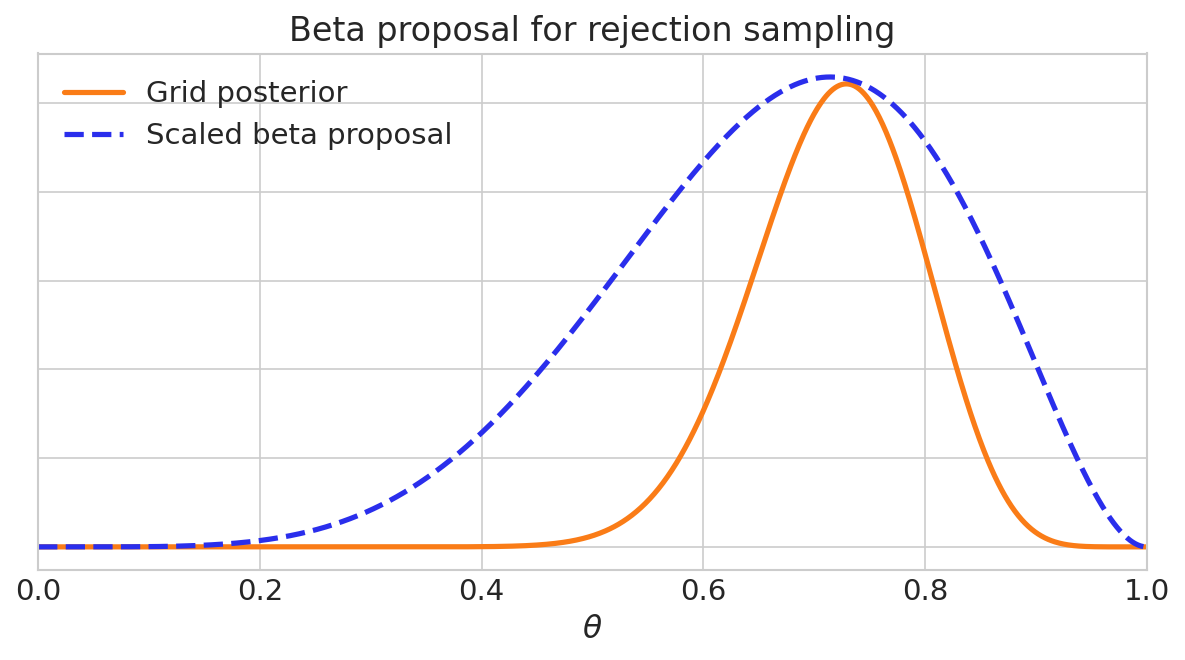

{'posterior_mean': np.float64(0.7183128554005092),
 'posterior_std': np.float64(0.07541398075108302),
 'proposal_alpha': 6,
 'proposal_beta': 3,
 'proposal_scale': np.float64(2.075657698534105)}

In [76]:
posterior_mean = np.trapezoid(theta_grid * posterior_grid, theta_grid)
posterior_variance = np.trapezoid((theta_grid - posterior_mean)**2 * posterior_grid, theta_grid)
posterior_std = np.sqrt(posterior_variance)

proposal_alpha = 6
proposal_beta = 3
proposal_dist = stats.beta(proposal_alpha, proposal_beta)
proposal_sampler = proposal_dist.rvs
proposal_pdf = proposal_dist.pdf(theta_grid)
proposal_scale = 1.01 * np.max(posterior_grid / proposal_pdf)
scaled_proposal_pdf = proposal_scale * proposal_pdf

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_grid, posterior_grid, color='C1', linewidth=2.5, label='Grid posterior')
ax.plot(theta_grid, scaled_proposal_pdf, color='C0', linewidth=2.5, linestyle='--', label='Scaled beta proposal')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('')
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_title('Beta proposal for rejection sampling')
ax.set_xlim(lower, upper)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

{
    'posterior_mean': posterior_mean,
    'posterior_std': posterior_std,
    'proposal_alpha': proposal_alpha,
    'proposal_beta': proposal_beta,
    'proposal_scale': proposal_scale,
}


C:\Users\User\AppData\Local\Temp\ipykernel_33728\274257148.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


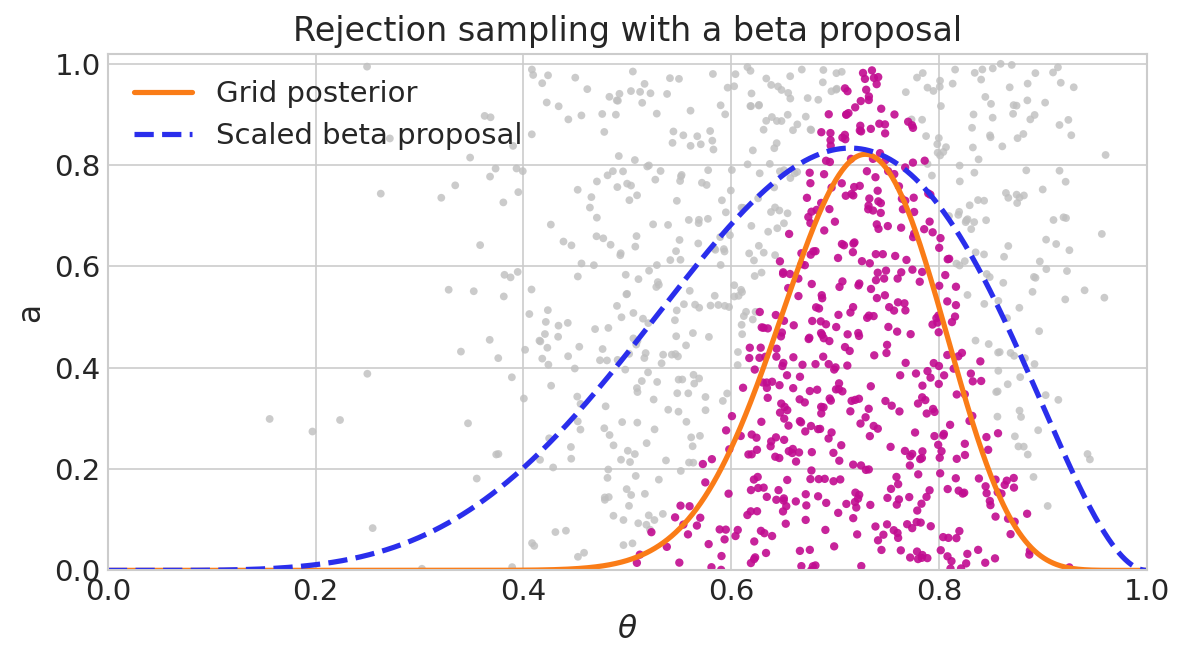

{'num_draws': 1000, 'num_accepted': 498, 'acceptance_rate': 0.498}

In [77]:
theta = proposal_sampler(size=1000, random_state=123)
a = rng.uniform(0, 1, size=1000)

posterior_at_theta = np.interp(theta, theta_grid, posterior_grid)
scaled_proposal_at_theta = np.interp(theta, theta_grid, scaled_proposal_pdf)
acceptance_ratio = posterior_at_theta / scaled_proposal_at_theta
accepted = a < acceptance_ratio

proposal_peak = scaled_proposal_pdf.max()*1.2
posterior_normalized = posterior_grid / proposal_peak
proposal_normalized = scaled_proposal_pdf / proposal_peak

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_grid, posterior_normalized, color='C1', linewidth=2.5, label='Grid posterior')
ax.plot(theta_grid, proposal_normalized, color='C0', linewidth=2.5, linestyle='--', label='Scaled beta proposal')
ax.scatter(theta[~accepted], a[~accepted], color='0.75', s=14, alpha=0.8, edgecolors='none')
ax.scatter(theta[accepted], a[accepted], color='C3', s=16, alpha=0.9, edgecolors='none')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('a')
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_title('Rejection sampling with a beta proposal')
ax.set_xlim(lower, upper)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

{
    'num_draws': len(theta),
    'num_accepted': int(np.sum(accepted)),
    'acceptance_rate': float(np.mean(accepted)),
}


C:\Users\User\AppData\Local\Temp\ipykernel_33728\1392861300.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


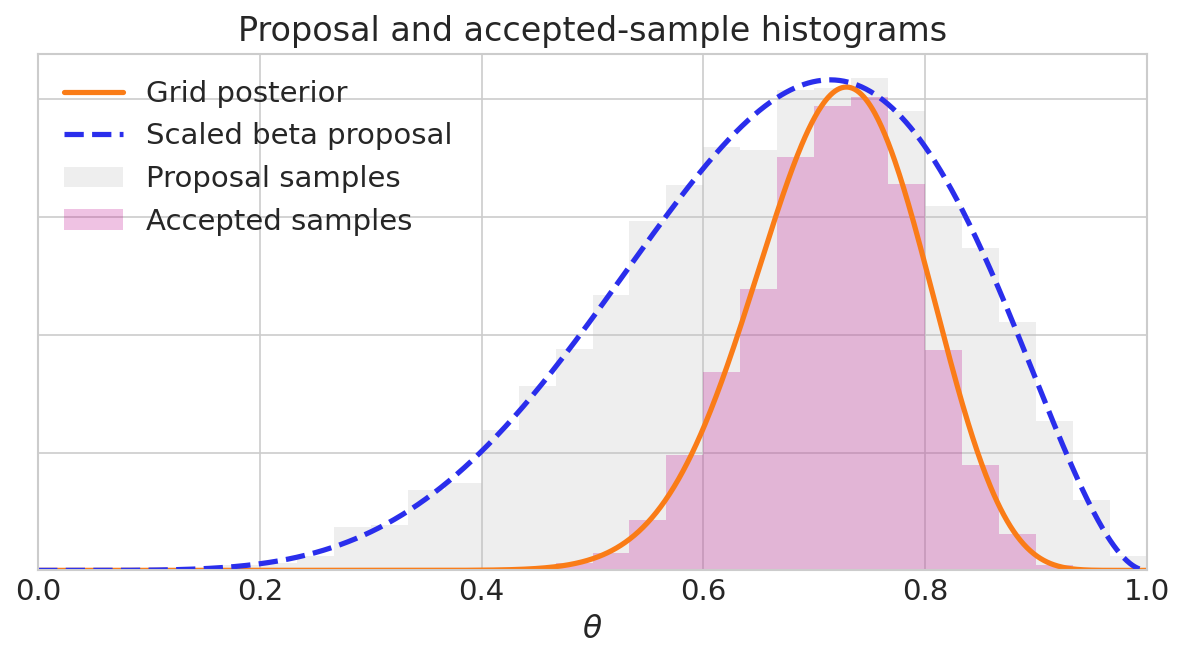

{'num_proposal_samples': 10000,
 'num_accepted_samples': 4817,
 'acceptance_rate': 0.4817}

In [78]:
theta_many = proposal_sampler(size=10_000, random_state=456)
a_many = rng.uniform(0, 1, size=10_000)

posterior_at_theta_many = np.interp(theta_many, theta_grid, posterior_grid)
scaled_proposal_at_theta_many = np.interp(theta_many, theta_grid, scaled_proposal_pdf)
accepted_many = a_many < (posterior_at_theta_many / scaled_proposal_at_theta_many)

bins = np.linspace(lower, upper, 31)
proposal_hist_density, _ = np.histogram(theta_many, bins=bins, density=True)
accepted_hist_density, _ = np.histogram(theta_many[accepted_many], bins=bins, density=True)

proposal_hist_normalized = proposal_hist_density * proposal_scale / proposal_peak
accepted_hist_normalized = accepted_hist_density / proposal_peak

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theta_grid, posterior_normalized, color='C1', linewidth=2.5, label='Grid posterior')
ax.plot(theta_grid, proposal_normalized, color='C0', linewidth=2.5, linestyle='--', label='Scaled beta proposal')
ax.stairs(proposal_hist_normalized, bins, color='0.75', linewidth=1.5, fill=True, alpha=0.25, label='Proposal samples')
ax.stairs(accepted_hist_normalized, bins, color='C3', linewidth=1.5, fill=True, alpha=0.25, label='Accepted samples')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('')
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_title('Proposal and accepted-sample histograms')
ax.set_xlim(lower, upper)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

{
    'num_proposal_samples': len(theta_many),
    'num_accepted_samples': int(np.sum(accepted_many)),
    'acceptance_rate': float(np.mean(accepted_many)),
}


### Still missing in this section
- The lecture's rejection-sampling construction for the non-conjugate posterior.
- The specific rejection-sampling failure modes from slides 9-12.
- Any slide-specific visual styling beyond the inline conjugate-posterior example.


<a id="section-43"></a>
## 4.3 Monte-Carlo Markov Chain
### A random walk that converges to the target distribution
Slides 13-15 move from generic sampling to MCMC. The next cells were brought in from [Lecture05_MCMC.ipynb](/d:/Repositories/StatisticalComputationAndAnalysis/Notebooks/Lecture05_MCMC.ipynb) because they already implement the discrete-state random-walk example used to build the intuition for the section.


<a id="section-44"></a>
## 4.4 Metropolis
### The simplest MCMC algorithm
These cells align most closely with slides 17-24: defining a target distribution, following a chain over time, and showing that the empirical distribution approaches the target. The detailed-balance derivation and the Metropolis-Hastings extension from slides 25-29 still need more lecture-specific notebook treatment later.


C:\Users\User\AppData\Local\Temp\ipykernel_33728\2328094042.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


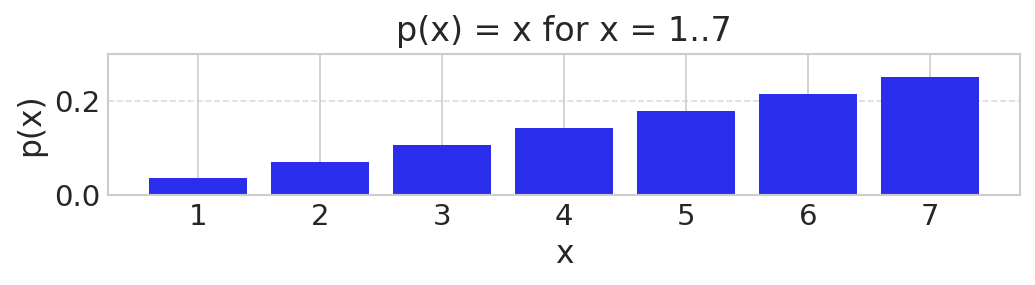

In [79]:
x = np.arange(1, 8)
p = x / np.sum(x)  # normalize probabilities

plt.figure(figsize=(7, 2))
plt.bar(x, p, color='C0')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('p(x) = x for x = 1..7')
plt.xticks(x)
plt.ylim(0, max(p) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_33728\1485438746.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


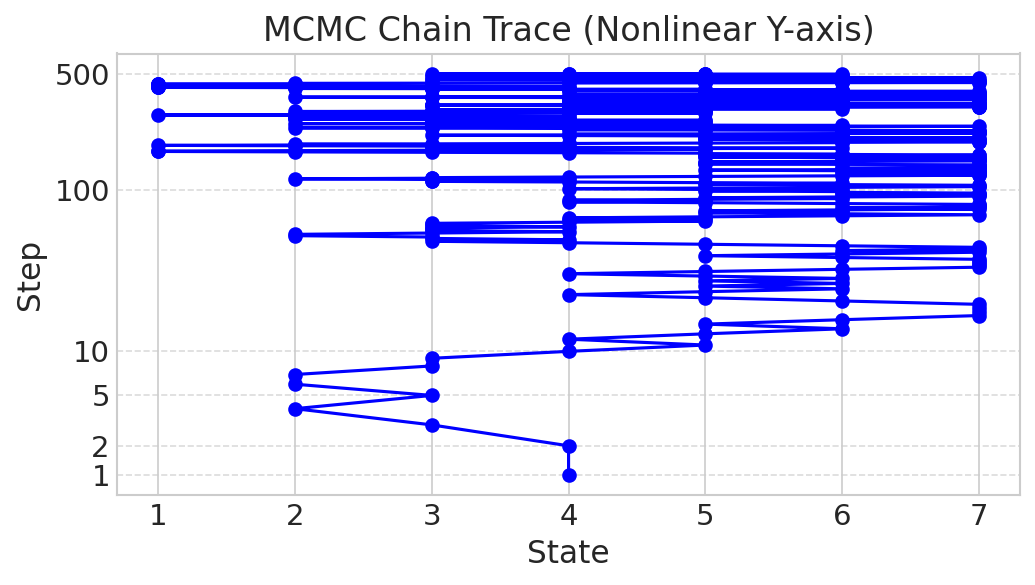

In [80]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

states = np.arange(1, 8)
p = states / np.sum(states)

chain = [4]
num_steps = 500

for _ in range(num_steps):
    current = chain[-1]
    proposal = current + np.random.choice([-1, 1])
    if proposal < 1 or proposal > 7:
        proposal = current
    accept_prob = min(1, p[proposal - 1] / p[current - 1])
    if np.random.rand() < accept_prob:
        chain.append(proposal)
    else:
        chain.append(current)

# Plotting
plt.figure(figsize=(7, 4))
# Plot step number nonlinearly scaled
y_positions = np.log1p(np.arange(1, num_steps+2))  # log scale for step number
plt.plot(chain, y_positions, color='b', marker='o') # drawstyle='steps-post', 

plt.xlabel('State')
plt.ylabel('Step')
plt.title('MCMC Chain Trace (Nonlinear Y-axis)')
plt.yticks(
    np.log1p([1, 2, 5, 10, 100, 500]),
    ['1', '2', '5', '10', '100', '500']
)
# plt.gca().invert_yaxis()  # Step 1 at the bottom, Step 500 at the top
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_33728\3438509444.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


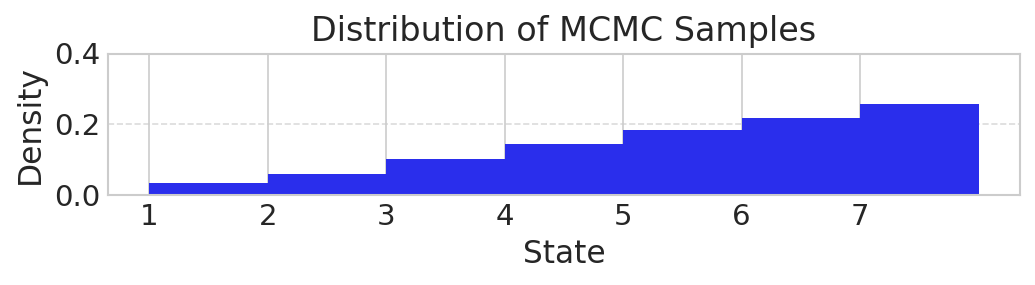

In [81]:
chain = [4]
num_steps = 10000

for _ in range(num_steps):
    current = chain[-1]
    proposal = current + np.random.choice([-1, 1])
    if proposal < 1 or proposal > 7:
        proposal = current
    accept_prob = min(1, p[proposal - 1] / p[current - 1])
    if np.random.rand() < accept_prob:
        chain.append(proposal)

# Generate samples from the chain
samples = np.array(chain)

# Create the figure
plt.figure(figsize=(7, 2))
plt.hist(samples, bins=range(1, 9), density=True, color='C0')
plt.xlabel('State')
plt.ylabel('Density')
plt.title('Distribution of MCMC Samples')
plt.xticks(range(1, 8))
plt.ylim(0, 0.4)  # Setting similar y-axis limits as the original distribution
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_33728\2124452493.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


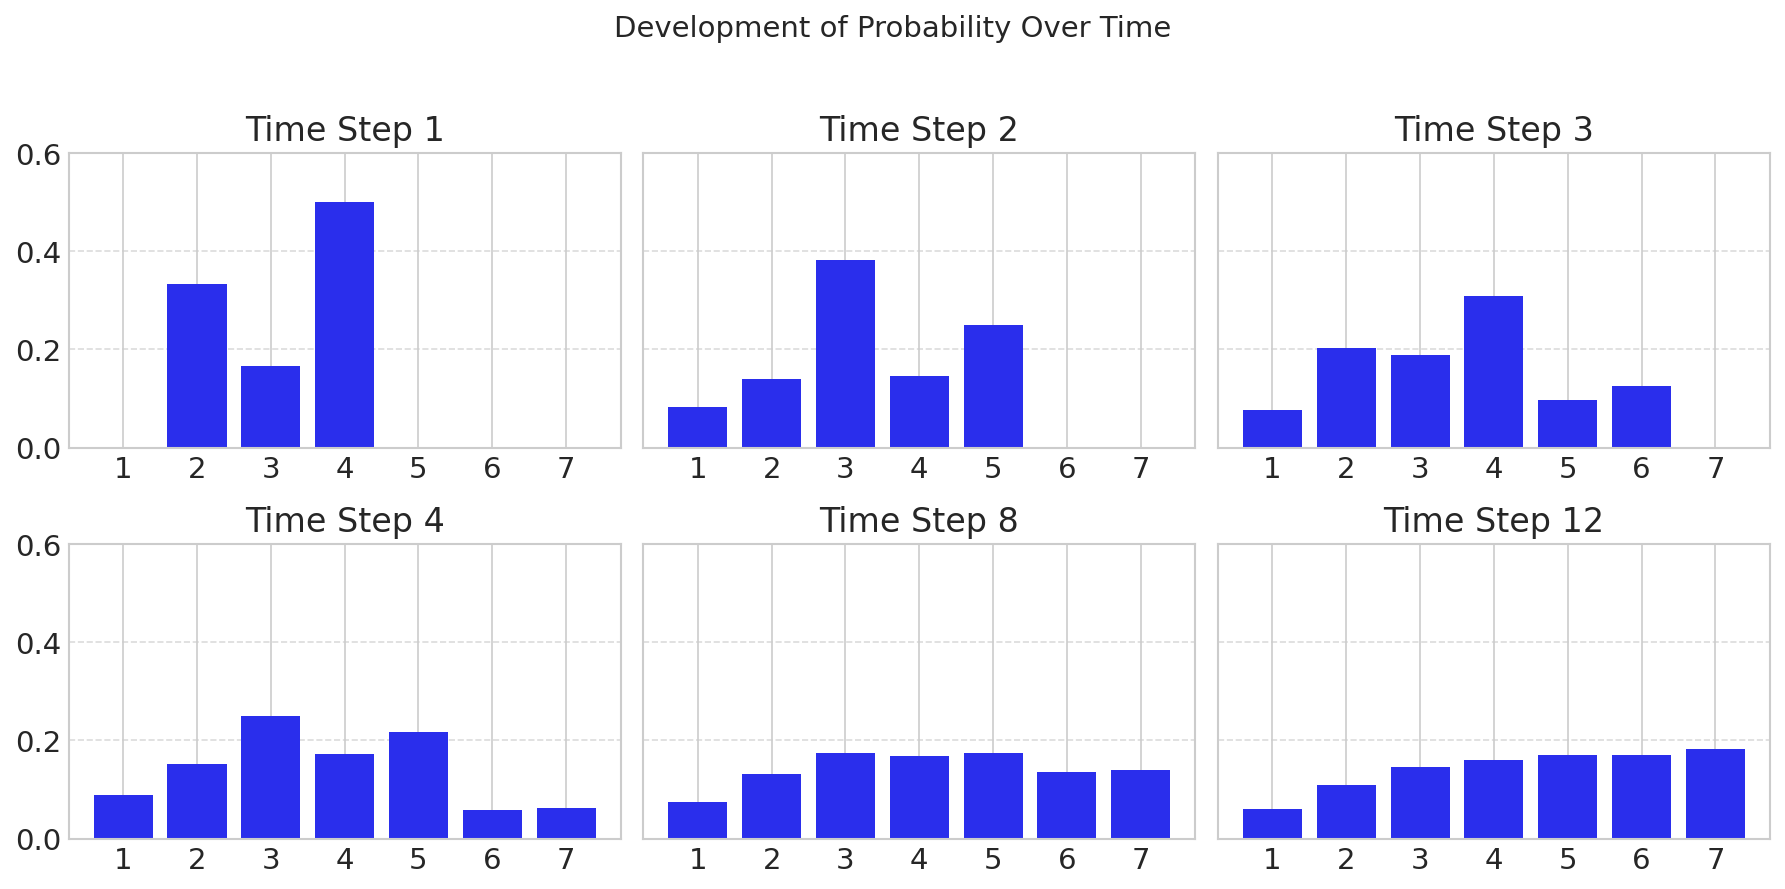

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# States 1 to 7
states = np.arange(1, 8)

# Transition matrix
transition = np.zeros((7, 7))
for i in range(7):
    for j in [-1, 1]:  # Propose left or right
        neighbor = i + j
        if 0 <= neighbor < 7:
            # Acceptance probability = min(1, p(neighbor)/p(current)) = neighbor+1/(i+1)
            accept_prob = min(1, (neighbor + 1) / (i + 1))
            transition[i, neighbor] += 0.5 * accept_prob
            transition[i, i] += 0.5 * (1 - accept_prob)  # Stay if rejected
        else:
            transition[i, i] += 0.5  # Boundary reflects, stay put

# Normalize rows (not strictly necessary, but double-checking)
transition = transition / transition.sum(axis=1, keepdims=True)

# Initial distribution: all probability at state 4 (index 3)
initial = np.zeros(7)
initial[2] = 1.0

# Time steps to plot
time_steps = [1, 2, 3, 4, 8, 12]
distributions = []

current = initial.copy()
for t in range(1, max(time_steps)+1):
    current = current @ transition
    if t in time_steps:
        distributions.append(current.copy())

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)

for ax, dist, t in zip(axes.flatten(), distributions, time_steps):
    ax.bar(states, dist, color='C0')
    ax.set_title(f'Time Step {t}')
    ax.set_xticks(states)
    ax.set_ylim(0, 0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.suptitle('Development of Probability Over Time', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_33728\3173524988.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


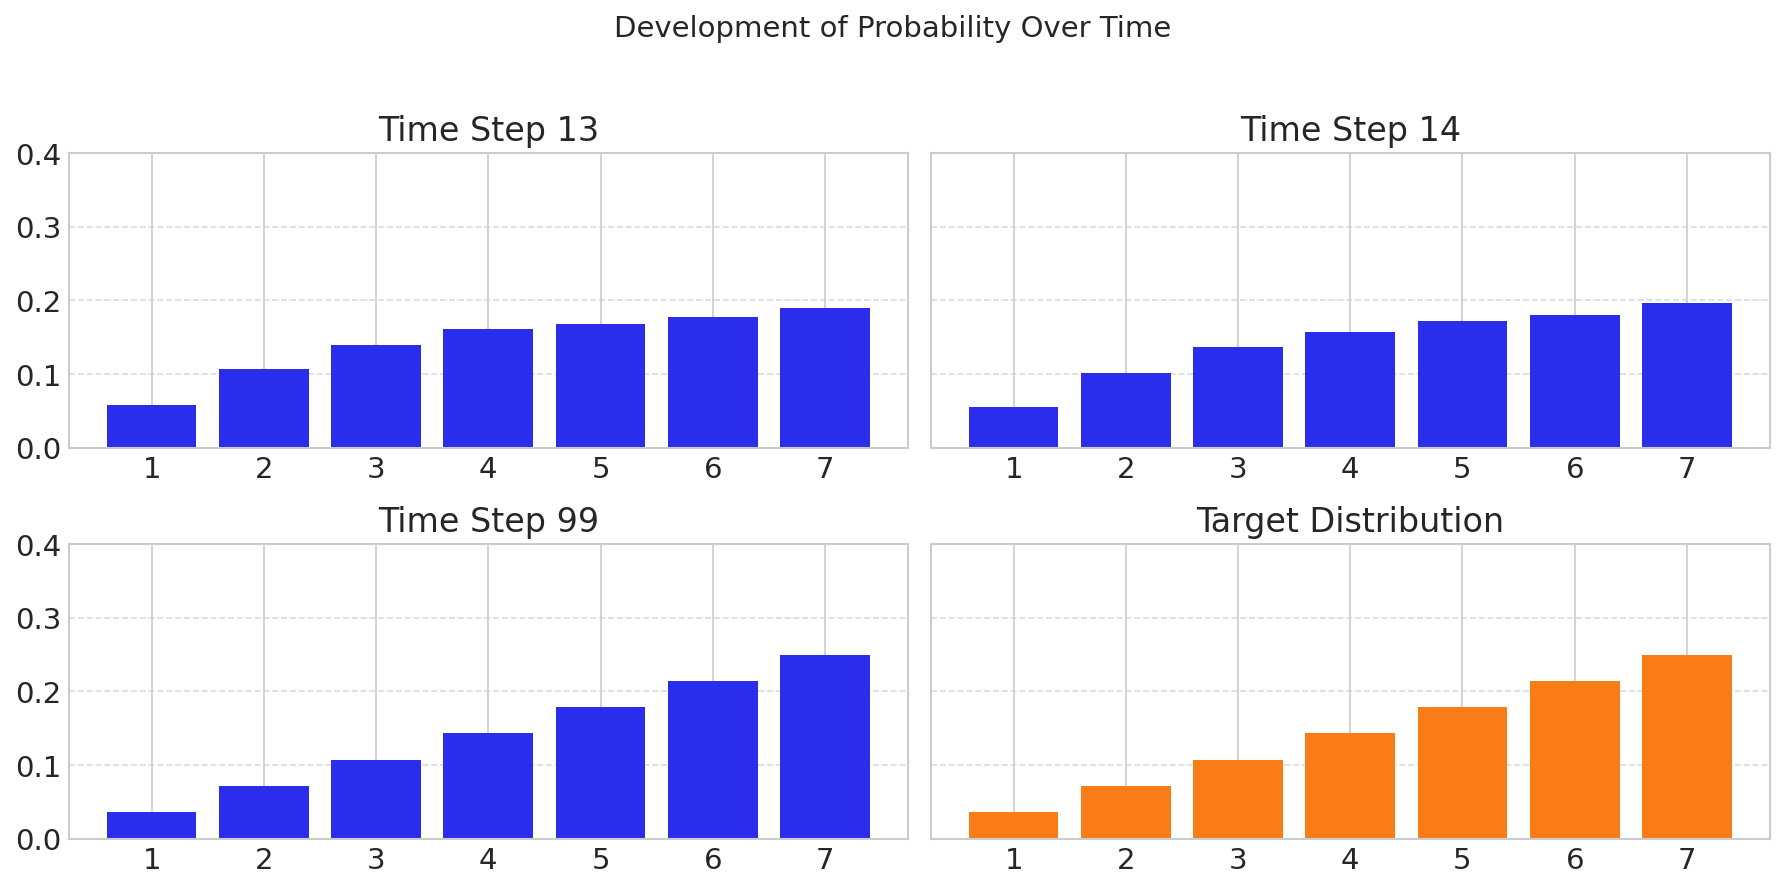

In [83]:
# Continue from previous time steps analysis
# Calculate distributions for time steps 13, 14, 99, and the target (stationary) distribution
time_steps_new = [13, 14, 99]
distributions_new = []

# Start from the last distribution we already have (t=12)
current = distributions[-1].copy()
for t in range(13, max(time_steps_new)+1):
    current = current @ transition
    if t in time_steps_new:
        distributions_new.append(current.copy())

# Calculate the stationary/target distribution
target_dist = states / np.sum(states)  # This is the target distribution p(x) = x/sum(x)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True)
axes = axes.flatten()

# Plot the time steps
for ax, dist, t in zip(axes[:3], distributions_new, time_steps_new):
    ax.bar(states, dist, color='C0')
    ax.set_title(f'Time Step {t}')
    ax.set_xticks(states)
    ax.set_ylim(0, 0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Plot the target distribution
axes[3].bar(states, target_dist, color='C1')
axes[3].set_title('Target Distribution')
axes[3].set_xticks(states)
axes[3].set_ylim(0, 0.4)
axes[3].grid(axis='y', linestyle='--', alpha=0.7)

fig.suptitle('Development of Probability Over Time', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Still missing in this section
- The acceptance-rule walkthrough with explicit proposal probabilities.
- The detailed-balance algebra from slides 25-27.
- The Metropolis-Hastings asymmetric-proposal example from slide 28.
- The proposal-scale tuning demo from slide 29.


<a id="section-45"></a>
## 4.5 Sampling diagnostics
### Trace plots, R-hat, ESS, and MCSE
Slides 31-40 now use the same truncated-normal binomial model from section 4.2. We sample that one-parameter posterior with Metropolis twice. Both runs use **no proposal adaptation** (`tune=False`) and **no PyMC warmup** (`tune=0`). The chains start from the same deliberately dispersed initial values; only the proposal scale changes: 0.30 for the good run and 0.05 for the bad run. We manually treat the first 500 draws as warmup, plot the warmup convergence for both, and then surgically discard those draws before computing the standard diagnostics.

In [84]:
metropolis_seed = 367
total_draws = 2_500
warmup_draws = 500

metropolis_initvals = [
    {'theta': 0.05},
    {'theta': 0.25},
    {'theta': 0.85},
    {'theta': 0.98},
]

metropolis_settings = {
    'good': {'label': 'Good Metropolis', 'scaling': 0.30, 'color': 'C0'},
    'bad': {'label': 'Bad Metropolis', 'scaling': 0.05, 'color': 'C3'},
}

with nonconjugate_binomial_model:
    good_metropolis_step = pm.Metropolis(
        scaling=metropolis_settings['good']['scaling'],
        tune=False,
    )
    idata_metropolis_good_raw = pm.sample(
        draws=total_draws,
        tune=0,
        chains=4,
        cores=1,
        step=good_metropolis_step,
        initvals=metropolis_initvals,
        random_seed=metropolis_seed,
        progressbar=False,
        compute_convergence_checks=False,
    )

with nonconjugate_binomial_model:
    bad_metropolis_step = pm.Metropolis(
        scaling=metropolis_settings['bad']['scaling'],
        tune=False,
    )
    idata_metropolis_bad_raw = pm.sample(
        draws=total_draws,
        tune=0,
        chains=4,
        cores=1,
        step=bad_metropolis_step,
        initvals=metropolis_initvals,
        random_seed=metropolis_seed,
        progressbar=False,
        compute_convergence_checks=False,
    )

{
    'draws_per_chain': total_draws,
    'manual_warmup_draws': warmup_draws,
    'initial_theta_values': [initval['theta'] for initval in metropolis_initvals],
    'metropolis_scaling': {
        name: settings['scaling'] for name, settings in metropolis_settings.items()
    },
}

Sequential sampling (4 chains in 1 job)
Metropolis: [theta]
Sampling 4 chains for 0 tune and 2_500 draw iterations (0 + 10_000 draws total) took 1 seconds.
Sequential sampling (4 chains in 1 job)
Metropolis: [theta]
Sampling 4 chains for 0 tune and 2_500 draw iterations (0 + 10_000 draws total) took 1 seconds.


{'draws_per_chain': 2500,
 'manual_warmup_draws': 500,
 'initial_theta_values': [0.05, 0.25, 0.85, 0.98],
 'metropolis_scaling': {'good': 0.3, 'bad': 0.05}}

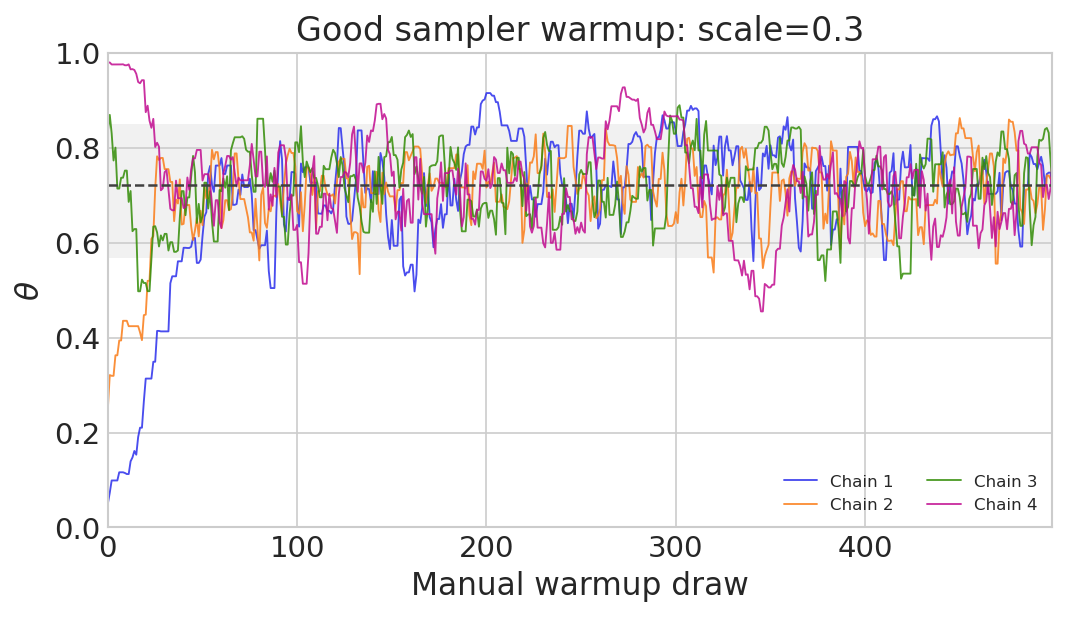

In [85]:
def running_rhat_early(idata, var_name='theta', warmup_end=None, step=25):
    end = warmup_end if warmup_end is not None else idata.posterior.sizes['draw']
    iterations = np.arange(step, end + 1, step)
    values = []
    for n in iterations:
        subset = idata.posterior.isel(draw=slice(0, n))
        temp_idata = az.InferenceData(posterior=subset)
        values.append(float(az.rhat(temp_idata, var_names=[var_name])[var_name].values))
    return iterations, np.array(values)


def plot_warmup_convergence(ax, idata, title, reference_interval):
    warmup_values = idata.posterior['theta'].values[:, :warmup_draws]
    warmup_index = np.arange(warmup_draws)
    for chain_idx, chain_values in enumerate(warmup_values):
        ax.plot(
            warmup_index,
            chain_values,
            color=f'C{chain_idx}',
            alpha=0.85,
            linewidth=0.9,
            label=f'Chain {chain_idx + 1}',
        )
    ax.axhspan(
        reference_interval[0],
        reference_interval[2],
        color='0.85',
        alpha=0.35,
        linewidth=0,
        zorder=-2,
    )
    ax.axhline(reference_interval[1], color='0.25', linestyle='--', linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Manual warmup draw')
    ax.set_ylabel(r'$\theta$')
    ax.set_xlim(0, warmup_draws - 1)
    ax.set_ylim(lower, upper)


posterior_cdf = np.cumsum(posterior_grid)
posterior_cdf = posterior_cdf / posterior_cdf[-1]
posterior_reference_interval = np.interp([0.03, 0.50, 0.97], posterior_cdf, theta_grid)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
plot_warmup_convergence(
    ax,
    idata_metropolis_good_raw,
    f"Good sampler warmup: scale={metropolis_settings['good']['scaling']}",
    posterior_reference_interval,
)
ax.legend(frameon=False, ncol=2, fontsize=8, loc='lower right')
plt.show()

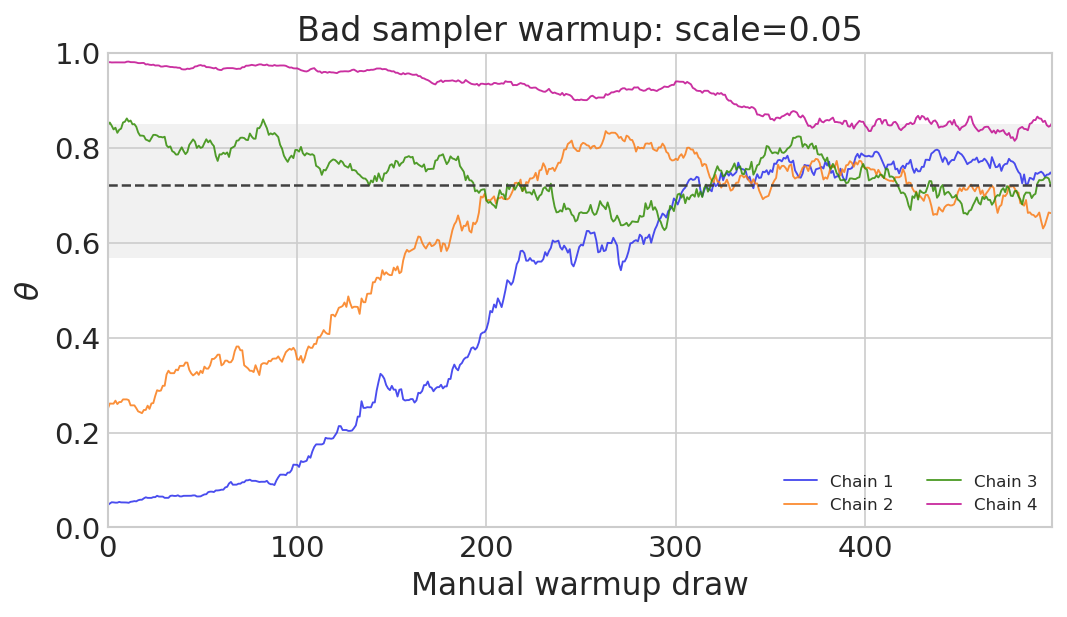

In [86]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
plot_warmup_convergence(
    ax,
    idata_metropolis_bad_raw,
    f"Bad sampler warmup: scale={metropolis_settings['bad']['scaling']}",
    posterior_reference_interval,
)
ax.legend(frameon=False, ncol=2, fontsize=8, loc='lower right')
plt.show()

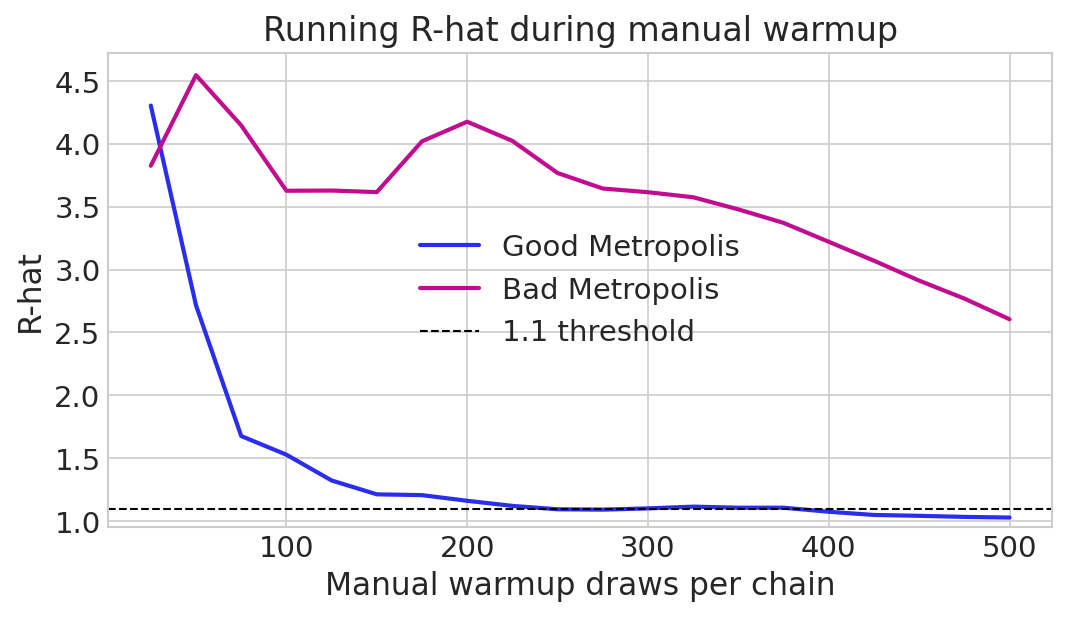

In [87]:
good_iters, good_rhat_w = running_rhat_early(idata_metropolis_good_raw, warmup_end=warmup_draws)
bad_iters, bad_rhat_w = running_rhat_early(idata_metropolis_bad_raw, warmup_end=warmup_draws)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(
    good_iters,
    good_rhat_w,
    color=metropolis_settings['good']['color'],
    linewidth=2,
    label=metropolis_settings['good']['label'],
)
ax.plot(
    bad_iters,
    bad_rhat_w,
    color=metropolis_settings['bad']['color'],
    linewidth=2,
    label=metropolis_settings['bad']['label'],
)
ax.axhline(1.1, color='black', linestyle='--', linewidth=1, label='1.1 threshold')
ax.set_xlabel('Manual warmup draws per chain')
ax.set_ylabel('R-hat')
ax.set_title('Running R-hat during manual warmup')
ax.set_ylim(bottom=0.95)
ax.legend(frameon=False)
plt.show()

### Surgery: discarding the warmup draws
Both raw `idata` objects hold `total_draws` samples per chain. The cells below slice away the first `warmup_draws` draws (the burn-in period shown above) and create new post-warmup `idata` objects. Keeping the raw objects separate makes the surgery idempotent: rerunning this cell does not keep shaving off another 500 draws.

In [88]:
def discard_manual_warmup(idata, warmup):
    posterior = (
        idata.posterior
        .isel(draw=slice(warmup, None))
        .assign_coords(draw=np.arange(idata.posterior.sizes['draw'] - warmup))
    )
    return az.InferenceData(posterior=posterior)


idata_metropolis_good = discard_manual_warmup(idata_metropolis_good_raw, warmup_draws)
idata_metropolis_bad = discard_manual_warmup(idata_metropolis_bad_raw, warmup_draws)

print(f"Post-surgery draws per chain: {idata_metropolis_good.posterior.sizes['draw']}")

Post-surgery draws per chain: 2000


### Trace plots reveal mixing and sticky chains
Neither run adapts its proposal; the contrast is purely the step size. The bad run's tiny scale means chains barely drift between draws, so four chains starting at very different values remain separated even after the manual warmup. The good run's larger scale produces rapid, well-mixed exploration across all chains.

Text(0.5, 0.98, 'Bad Metropolis sampling')

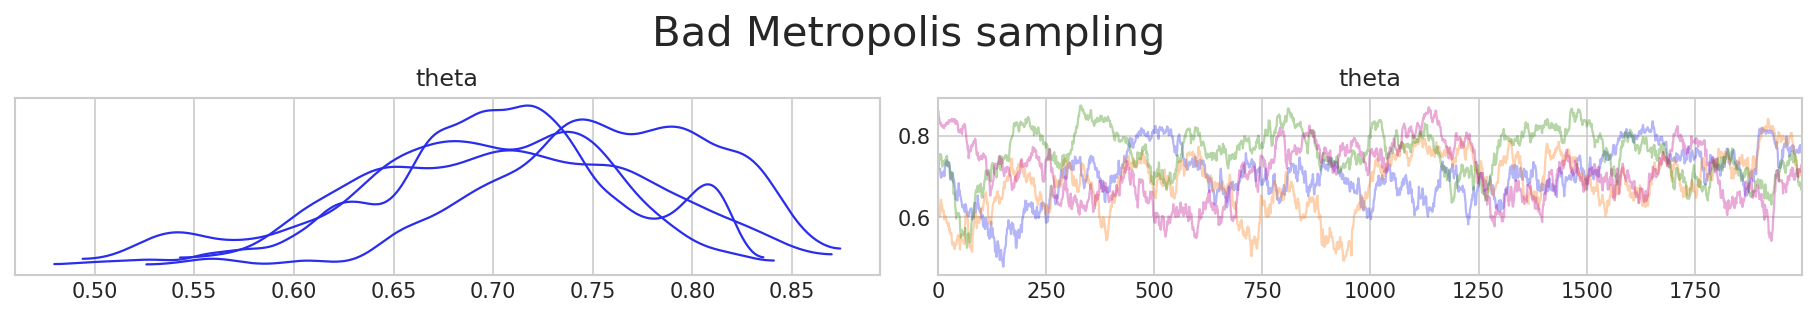

In [89]:
ax = az.plot_trace(
    idata_metropolis_bad,
    var_names=['theta'],
    chain_prop={'ls': '-'},
    compact=False,
)
ax[0, 0].get_figure().suptitle('Bad Metropolis sampling', fontsize=20)


Text(0.5, 0.98, 'Good Metropolis sampling')

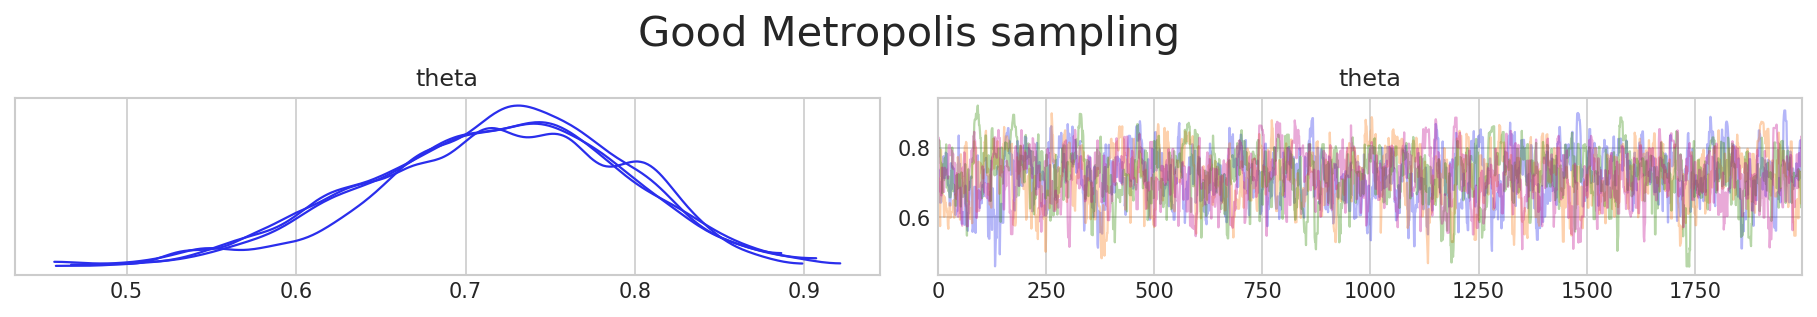

In [90]:
ax = az.plot_trace(
    idata_metropolis_good,
    var_names=['theta'],
    chain_prop={'ls': '-'},
    compact=False,
)
ax[0, 0].get_figure().suptitle('Good Metropolis sampling', fontsize=20)


C:\Users\User\AppData\Local\Temp\ipykernel_33728\1267637076.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


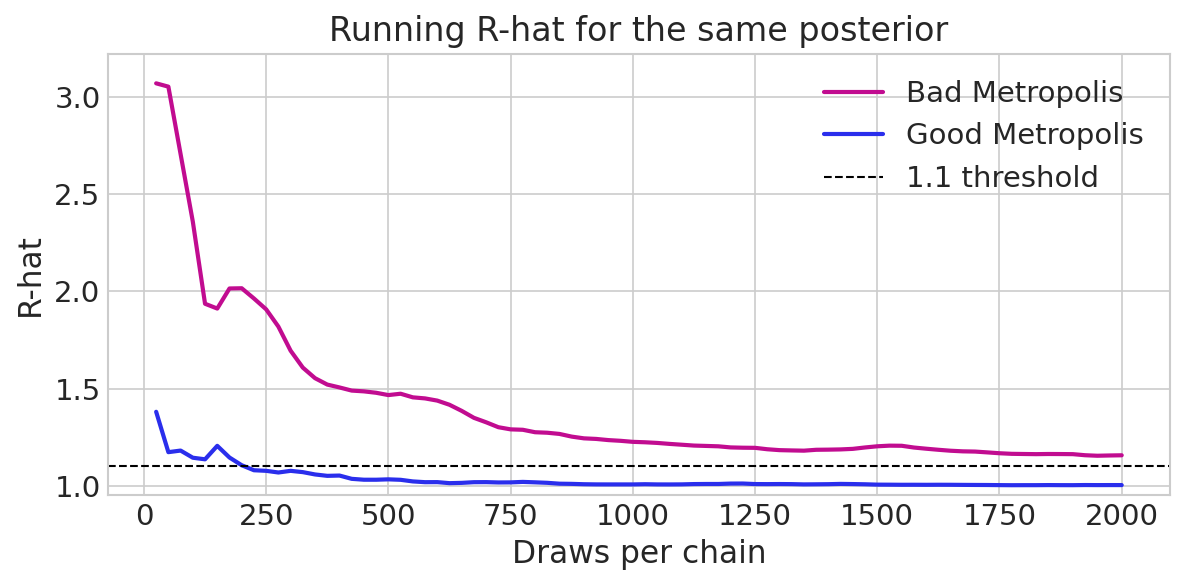

In [91]:
def running_rhat(idata, var_name='theta', step=25):
    num_draws = idata.posterior.sizes['draw']
    iterations = np.arange(step, num_draws + 1, step)
    values = []
    for draw_end in iterations:
        partial = idata.isel(draw=slice(0, draw_end))
        values.append(float(az.rhat(partial, var_names=[var_name])[var_name].values))
    return iterations, np.array(values)

bad_iterations, bad_rhat = running_rhat(idata_metropolis_bad, step=25)
good_iterations, good_rhat = running_rhat(idata_metropolis_good, step=25)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bad_iterations, bad_rhat, color='C3', linewidth=2, label='Bad Metropolis')
ax.plot(good_iterations, good_rhat, color='C0', linewidth=2, label='Good Metropolis')
ax.axhline(1.1, color='black', linestyle='--', linewidth=1, label='1.1 threshold')
ax.set_xlabel('Draws per chain')
ax.set_ylabel('R-hat')
ax.set_title('Running R-hat for the same posterior')
ax.set_ylim(0.95, max(1.2, np.nanmax(bad_rhat) * 1.05))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_33728\4273433727.py:10: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


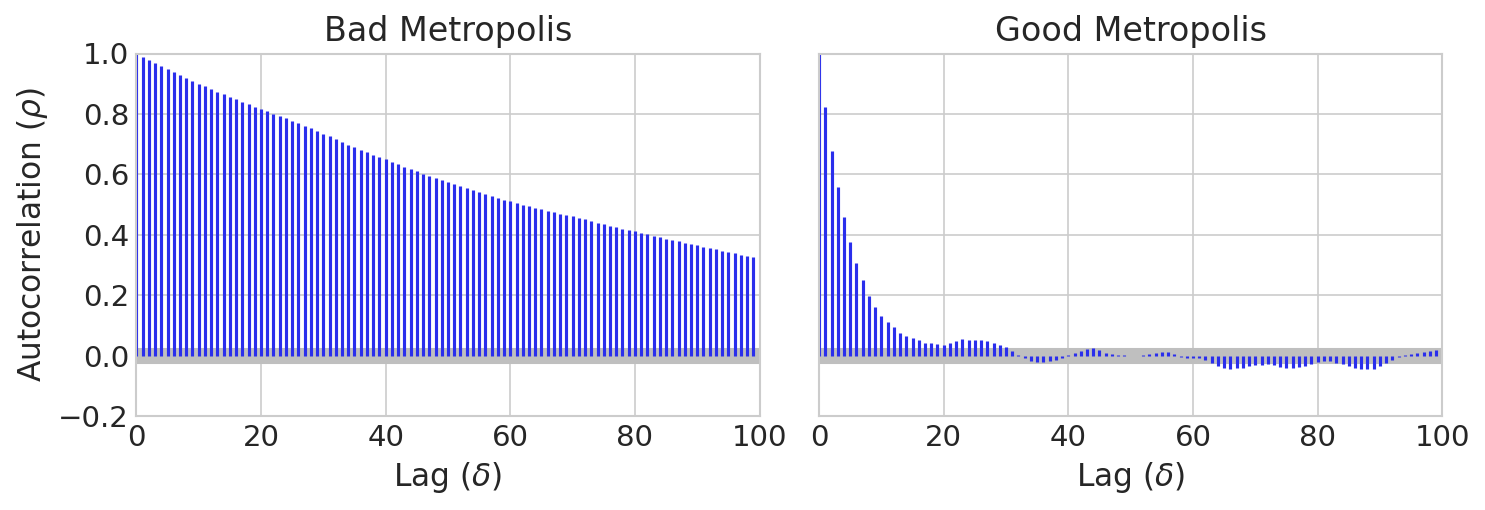

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
az.plot_autocorr(idata_metropolis_bad, var_names=['theta'], combined=True, ax=axes[0])
az.plot_autocorr(idata_metropolis_good, var_names=['theta'], combined=True, ax=axes[1])
axes[0].set_title('Bad Metropolis')
axes[1].set_title('Good Metropolis')
for ax in axes:
    ax.set_xlabel(r'Lag ($\delta$)')
    ax.set_ylim(-0.2, 1)
axes[0].set_ylabel(r'Autocorrelation ($\rho$)')
fig.tight_layout()
plt.show()


In [93]:
bad_diagnostics = az.summary(idata_metropolis_bad, var_names=['theta'], kind='diagnostics')
good_diagnostics = az.summary(idata_metropolis_good, var_names=['theta'], kind='diagnostics')

pd.concat(
    {'Bad Metropolis': bad_diagnostics, 'Good Metropolis': good_diagnostics},
    names=['run', 'parameter'],
)


,,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
run,parameter,,,,,
Bad Metropolis,theta,0.015,0.005,22.0,64.0,1.16
Good Metropolis,theta,0.003,0.001,732.0,1287.0,1.00


<a id="section-46"></a>
## 4.6 HMC and NUTS
### Typical sets, geometry, and gradient-based proposals
Slides 41-53 devote most of their space to HMC/NUTS geometry. The current notebook corpus only had one close match: the high-dimensional typical-set distance plot from the older MCMC notebook.


### Distance from the mode in high dimensions
This cell was brought in from [Lecture05_MCMC.ipynb](/d:/Repositories/StatisticalComputationAndAnalysis/Notebooks/Lecture05_MCMC.ipynb) because it matches slide 45 directly.


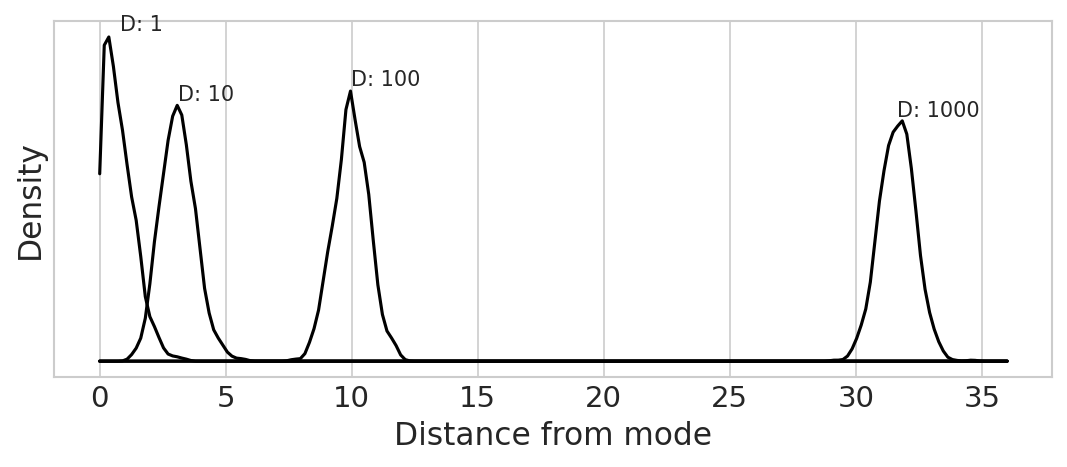

In [94]:
def rad_dist(Y):
    return np.sqrt(np.sum(Y**2))


fig, ax = plt.subplots(1, 1, figsize=[7, 3])
xvar = np.linspace(0, 36, 200)
# the book code is wrapped in a loop to reproduce Figure 9.4
for D in [1, 10, 100, 1000]:
    T = int(1e3)
    Y = stats.multivariate_normal(np.zeros(D), np.identity(D)).rvs(T)

    Rd = list(map(rad_dist, Y))

    kde = stats.gaussian_kde(Rd)
    yvar = kde(xvar)

    ax.plot(xvar, yvar, color="k")
    ax.text(np.mean(Rd), np.max(yvar) * 1.02, f"D: {D}")
    ax.set_xlabel('Distance from mode')
    ax.set_ylabel('Density')
    ax.set_yticks([])


### Still missing in this section
- The correlated-parameter Metropolis failure visuals.
- HMC trajectory geometry and momentum intuition from slides 43-52.
- The NUTS path-length / U-turn illustrations from slide 53.


<a id="section-47"></a>
## 4.7 Divergences
### HMC diagnostics on the same posterior
To continue the truncated-normal binomial example from sections 4.2 and 4.5, we now switch back to NUTS on **exactly the same posterior**. On this one-parameter model, lowering `max_treedepth` did not materially change the behavior, so this comparison keeps the code simple and focuses on the settings that actually changed the result: a well-tuned run with longer warmup and `target_accept=0.9`, versus a deliberately under-tuned run with shorter warmup and a too-small `target_accept=0.4`. That bad configuration produces a few divergences and a visibly rougher approximation even though the model itself has not changed.


In [95]:
nuts_seed = 367
nuts_draws = 800

nuts_settings = {
    'good': {
        'label': 'Good NUTS',
        'color': 'C0',
        'sample_kwargs': {'tune': 800, 'target_accept': 0.90},
    },
    'bad': {
        'label': 'Bad NUTS',
        'color': 'C3',
        'sample_kwargs': {'tune': 50, 'target_accept': 0.30},
    },
}

In [96]:
with nonconjugate_binomial_model:
    idata_nuts_good = pm.sample(
        draws=nuts_draws,
        chains=4,
        cores=1,
        random_seed=nuts_seed,
        progressbar=False,
        compute_convergence_checks=False,
        **nuts_settings['good']['sample_kwargs'],
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [theta]
Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 2 seconds.


In [97]:
with nonconjugate_binomial_model:
    idata_nuts_bad = pm.sample(
        draws=nuts_draws,
        chains=4,
        cores=1,
        random_seed=nuts_seed,
        progressbar=False,
        compute_convergence_checks=False,
        **nuts_settings['bad']['sample_kwargs'],
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [theta]
Sampling 4 chains for 50 tune and 800 draw iterations (200 + 3_200 draws total) took 1 seconds.


In [98]:
def extract_nuts_diagnostics(idata):
    return pd.DataFrame(
        {
            'theta': idata.posterior['theta'].values.reshape(-1),
            'energy': idata.sample_stats['energy'].values.reshape(-1),
            'diverging': idata.sample_stats['diverging'].values.reshape(-1).astype(bool),
        }
    )


good_nuts_df = extract_nuts_diagnostics(idata_nuts_good)
bad_nuts_df = extract_nuts_diagnostics(idata_nuts_bad)

posterior_cdf_local = np.cumsum(posterior_grid)
posterior_cdf_local = posterior_cdf_local / posterior_cdf_local[-1]
posterior_interval = np.interp([0.03, 0.50, 0.97], posterior_cdf_local, theta_grid)

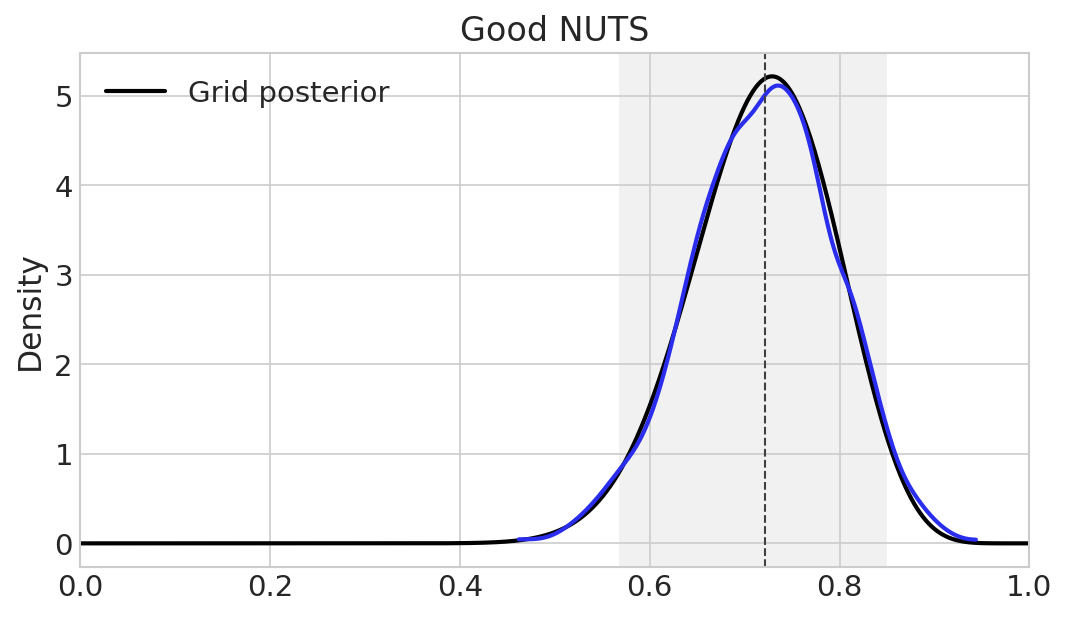

In [99]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(theta_grid, posterior_grid, color='black', linewidth=2, label='Grid posterior')
az.plot_kde(
    good_nuts_df['theta'].values,
    ax=ax,
    plot_kwargs={'color': nuts_settings['good']['color'], 'linewidth': 2},
)
ax.axvspan(
    posterior_interval[0],
    posterior_interval[2],
    color='0.85',
    alpha=0.35,
    linewidth=0,
    zorder=-2,
)
ax.axvline(posterior_interval[1], color='0.25', linestyle='--', linewidth=1)
ax.set_title(nuts_settings['good']['label'])
ax.set_ylabel('Density')
ax.set_xlim(lower, upper)
ax.legend(frameon=False)
plt.show()

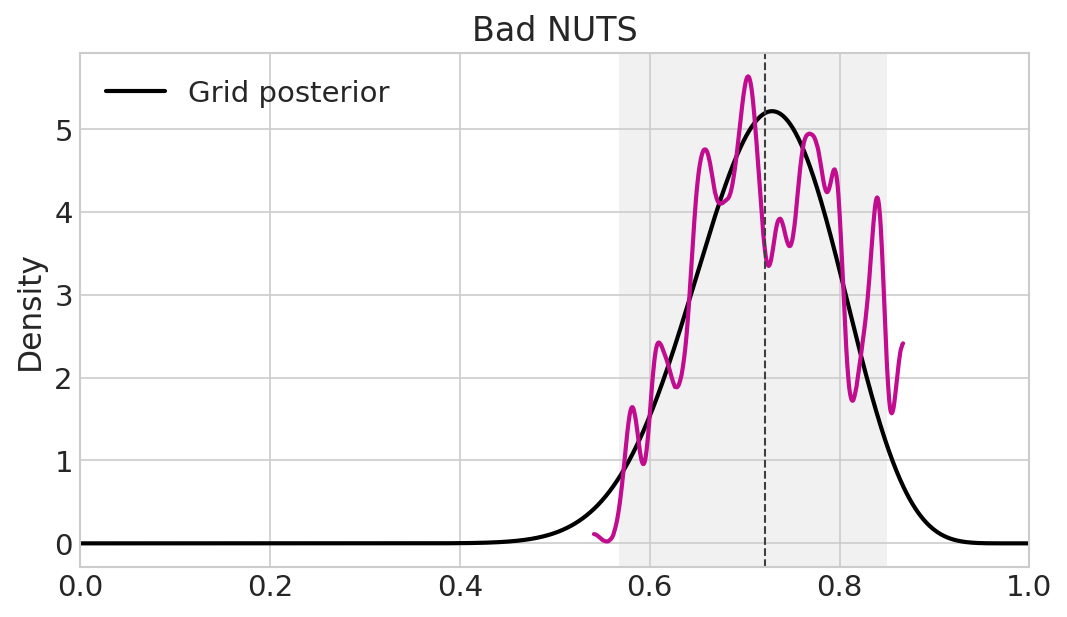

In [100]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(theta_grid, posterior_grid, color='black', linewidth=2, label='Grid posterior')
az.plot_kde(
    bad_nuts_df['theta'].values,
    ax=ax,
    plot_kwargs={'color': nuts_settings['bad']['color'], 'linewidth': 2},
)
ax.axvspan(
    posterior_interval[0],
    posterior_interval[2],
    color='0.85',
    alpha=0.35,
    linewidth=0,
    zorder=-2,
)
ax.axvline(posterior_interval[1], color='0.25', linestyle='--', linewidth=1)
ax.set_title(nuts_settings['bad']['label'])
ax.set_ylabel('Density')
ax.set_xlim(lower, upper)
ax.legend(frameon=False)
plt.show()

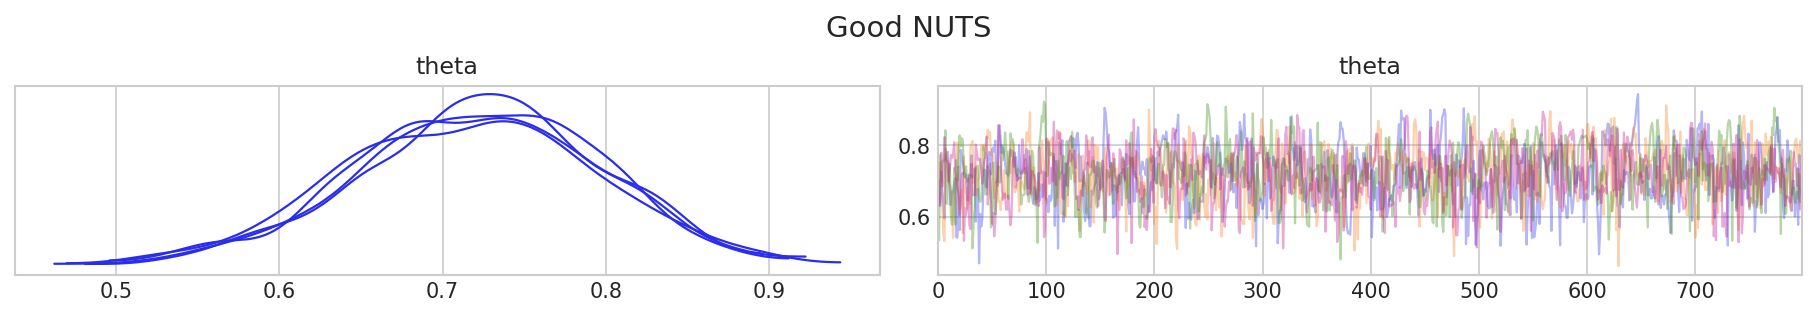

In [101]:
ax = az.plot_trace(
    idata_nuts_good,
    var_names=['theta'],
    chain_prop={'ls': '-'},
    compact=False,
)
ax[0, 0].get_figure().suptitle(nuts_settings['good']['label'], fontsize=14)
plt.show()

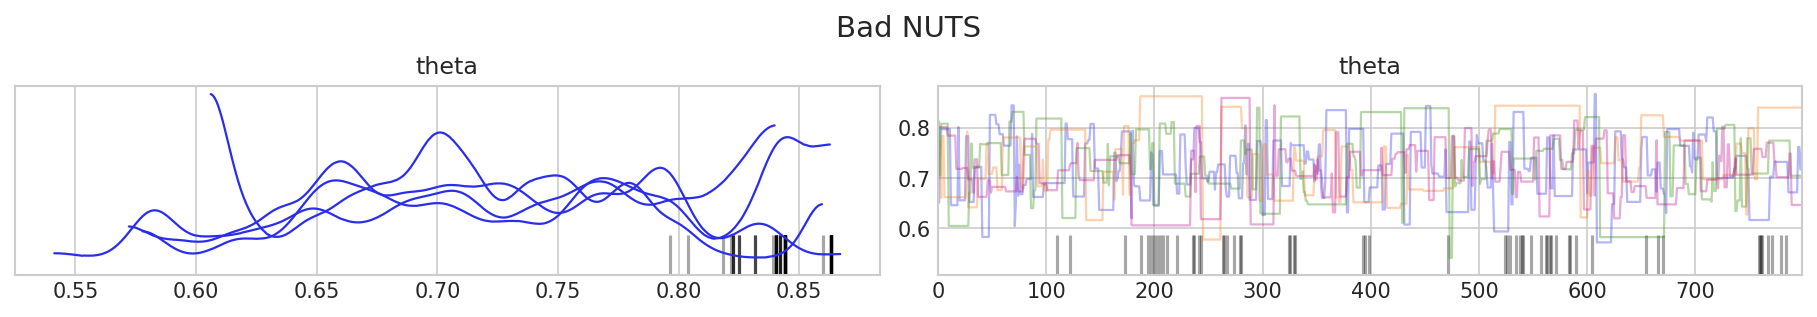

In [102]:
ax = az.plot_trace(
    idata_nuts_bad,
    var_names=['theta'],
    chain_prop={'ls': '-'},
    compact=False,
)
ax[0, 0].get_figure().suptitle(nuts_settings['bad']['label'], fontsize=14)
plt.show()

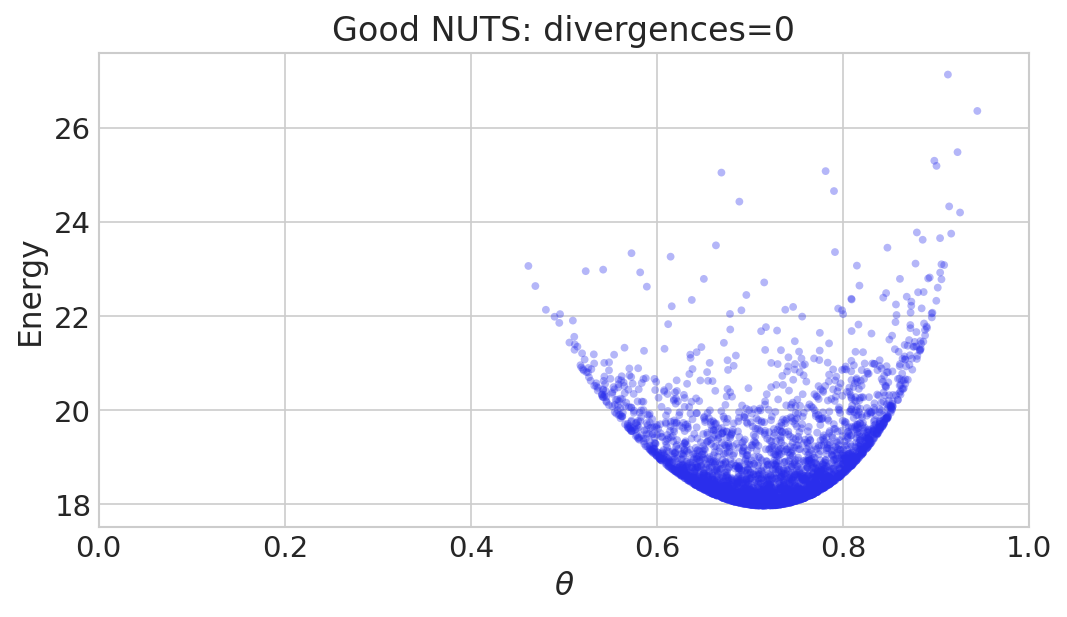

In [103]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
nondiv = good_nuts_df.loc[~good_nuts_df['diverging']]
div = good_nuts_df.loc[good_nuts_df['diverging']]
ax.scatter(
    nondiv['theta'],
    nondiv['energy'],
    color=nuts_settings['good']['color'],
    alpha=0.35,
    s=14,
    edgecolors='none',
)
if len(div):
    ax.scatter(
        div['theta'],
        div['energy'],
        color='black',
        alpha=0.9,
        s=18,
        marker='x',
        label='Divergent draw',
    )
    ax.legend(frameon=False, loc='upper left')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Energy')
ax.set_title(f"{nuts_settings['good']['label']}: divergences={int(good_nuts_df['diverging'].sum())}")
ax.set_xlim(lower, upper)
plt.show()

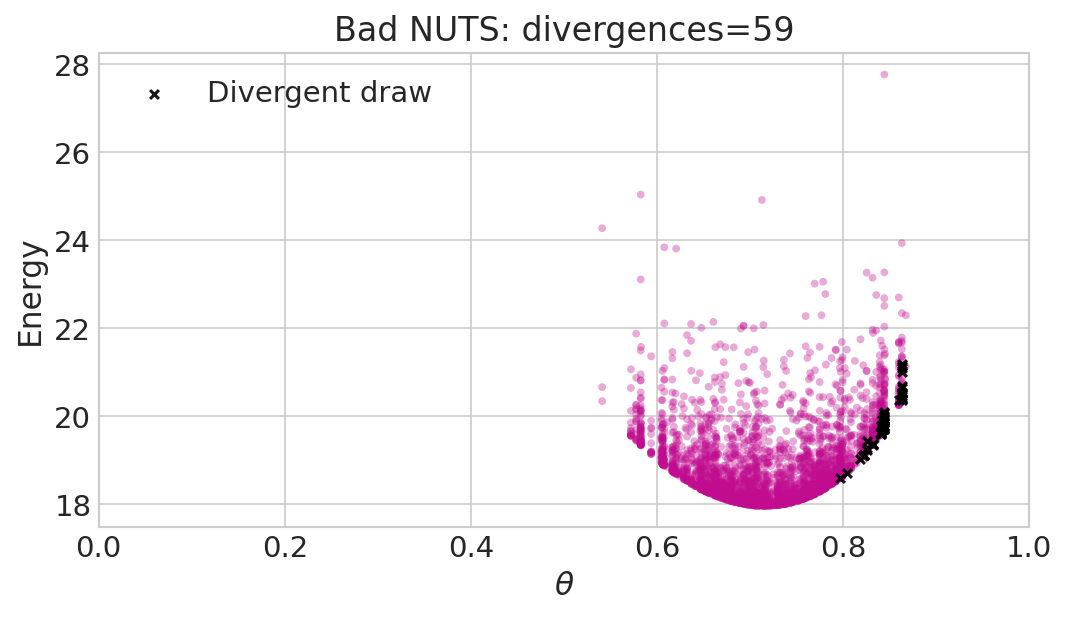

In [104]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
nondiv = bad_nuts_df.loc[~bad_nuts_df['diverging']]
div = bad_nuts_df.loc[bad_nuts_df['diverging']]
ax.scatter(
    nondiv['theta'],
    nondiv['energy'],
    color=nuts_settings['bad']['color'],
    alpha=0.35,
    s=14,
    edgecolors='none',
)
if len(div):
    ax.scatter(
        div['theta'],
        div['energy'],
        color='black',
        alpha=0.9,
        s=18,
        marker='x',
        label='Divergent draw',
    )
    ax.legend(frameon=False, loc='upper left')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Energy')
ax.set_title(f"{nuts_settings['bad']['label']}: divergences={int(bad_nuts_df['diverging'].sum())}")
ax.set_xlim(lower, upper)
plt.show()

In [105]:
summary_rows = [
    {
        'run': 'Grid posterior',
        'mean_theta': posterior_mean,
        'sd_theta': posterior_std,
        'mean_error': 0.0,
        'sd_error': 0.0,
        'divergences': 0,
        'ess_bulk': np.nan,
        'ess_tail': np.nan,
        'r_hat': np.nan,
    }
]

for name, idata in [('Good NUTS', idata_nuts_good), ('Bad NUTS', idata_nuts_bad)]:
    diagnostics = az.summary(idata, var_names=['theta'], kind='diagnostics')
    theta_samples = idata.posterior['theta'].values.reshape(-1)
    summary_rows.append(
        {
            'run': name,
            'mean_theta': float(theta_samples.mean()),
            'sd_theta': float(theta_samples.std(ddof=1)),
            'mean_error': float(theta_samples.mean() - posterior_mean),
            'sd_error': float(theta_samples.std(ddof=1) - posterior_std),
            'divergences': int(idata.sample_stats['diverging'].sum().values),
            'ess_bulk': float(diagnostics.loc['theta', 'ess_bulk']),
            'ess_tail': float(diagnostics.loc['theta', 'ess_tail']),
            'r_hat': float(diagnostics.loc['theta', 'r_hat']),
        }
    )

pd.DataFrame(summary_rows).set_index('run').round(4)

,mean_theta,sd_theta,mean_error,sd_error,divergences,ess_bulk,ess_tail,r_hat
run,,,,,,,,
Grid posterior,0.7183,0.0754,0.0000,0.0000,0,NaN,NaN,NaN
Good NUTS,0.7197,0.0753,0.0014,-0.0001,0,1095.0,1464.0,1.01
Bad NUTS,0.7261,0.0733,0.0077,-0.0021,59,131.0,74.0,1.03


### Still missing in this section
- The leapfrog-failure schematics from slides 55-56.
- The explicit trace-plot annotation used in slide 57.


<a id="section-48"></a>
## 4.8 PyTensor
### The machinery behind PyMC's probabilities and gradients
Slides 58-64 explain how PyMC hands off symbolic probability calculations to PyTensor. All examples below use the same `nonconjugate_binomial_model` from earlier in the lecture — no new data or model is introduced.

### Random variables, symbolic graph, and compiled log-density
The next cells show `nonconjugate_binomial_model`'s random variables, print the symbolic PyTensor graph for the observed node, and compile the log-density and its gradient at the model's initial point.

In [106]:
nonconjugate_binomial_model.basic_RVs

[theta ~ TruncatedNormal(0.5, 0.2, 0, 1), y ~ Bernoulli(theta)]

### Sampling from the generative model
`pm.draw` runs the model forward: first it draws $\theta$ from the TruncatedNormal prior, then draws 30 Bernoulli observations conditional on that $\theta$. Each row is one independent run of the full generative process.

In [107]:
for i in range(10):
    random_theta, random_y = pm.draw([theta_nonbeta, y_nonbeta])
    print(f"Sample {i}: theta = {random_theta:.4f}, y = {random_y}")

Sample 0: theta = 0.2788, y = [1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0]
Sample 1: theta = 0.5359, y = [0 1 1 0 1 1 1 0 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1]
Sample 2: theta = 0.1482, y = [0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0]
Sample 3: theta = 0.2696, y = [0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0]
Sample 4: theta = 0.6520, y = [1 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1]
Sample 5: theta = 0.5265, y = [0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 1 1 0 1 1 0 1 0 1 1]
Sample 6: theta = 0.3894, y = [0 1 0 1 0 1 1 1 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 0]
Sample 7: theta = 0.4345, y = [1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 1 1]
Sample 8: theta = 0.4322, y = [0 1 0 0 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 0 0 1 0]


Sample 9: theta = 0.2299, y = [0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 0 0]


### Slide 67 — The log joint probability density function
PyMC uses PyTensor to compile a function that returns the log probability of parameters *and* data, and its gradient. We draw one $\theta$ from the prior, pass it through the interval transform to get the unconstrained value PyMC works with internally, then evaluate both.

In [108]:
from scipy import special

sample_theta = pm.draw(theta_nonbeta)
theta_transformed = special.logit(sample_theta)

logp_func = nonconjugate_binomial_model.compile_logp()
dlogp_func = nonconjugate_binomial_model.compile_dlogp()

joint_logp = logp_func({"theta_interval__": theta_transformed})
gradient = dlogp_func({"theta_interval__": theta_transformed})

print(f"Sampled theta:         {sample_theta:.6f}")
print(f"Observed y:            {bernoulli_data}")
print(f"Joint log probability: {joint_logp:.6f}")
print(f"Gradient:              {gradient}")

Sampled theta:         0.497326
Observed y:            [1 1 1 1 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1]
Joint log probability: -21.563823
Gradient:              [8.10227314]


In [109]:
pytensor.dprint(y_nonbeta)

bernoulli_rv{"()->()"}.1 [id A] 'y'
 ├─ RNG(<Generator(PCG64) at 0x240675FB3E0>) [id B]
 ├─ [30] [id C]
 └─ ExpandDims{axis=0} [id D]
    └─ truncated_normal_rv{"(),(),(),()->()"}.1 [id E] 'theta'
       ├─ RNG(<Generator(PCG64) at 0x240675FAF80>) [id F]
       ├─ NoneConst{None} [id G]
       ├─ 0.5 [id H]
       ├─ 0.2 [id I]
       ├─ 0.0 [id J]
       └─ 1.0 [id K]


### Still missing in this section
- A closer notebook reproduction of the slide graphics for `basic_RVs` and the PyTensor relationship graph.
- A cleaner worked example of the symbolic-to-numeric gradient pipeline.


<a id="section-49"></a>
## 4.9 Workflow validation
### Prior predictive checks, diagnostics, and posterior predictive checks
Slides 65-76 return to the Bayesian workflow and apply all three checks to a concrete model. The original Lecture 4 notebook already had a strong Gaussian workflow example, so this pass keeps that block here and adds explicit markdown notes tying it to the lecture sequence.


### Prior predictive check — non-conjugate binomial model
Before examining the Gaussian workflow model, we check whether the truncated-normal prior implies reasonable data. The left panel shows the prior over $\theta$; the right panel shows the distribution of total successes implied by that prior across 1000 draws of 30 Bernoulli observations, with the observed count marked.

In [114]:
with nonconjugate_binomial_model:
    idata_binomial_prior = pm.sample_prior_predictive(samples=1000, random_seed=42)
idata_binomial_prior

Sampling: [theta, y]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

Sampling: [theta, y]


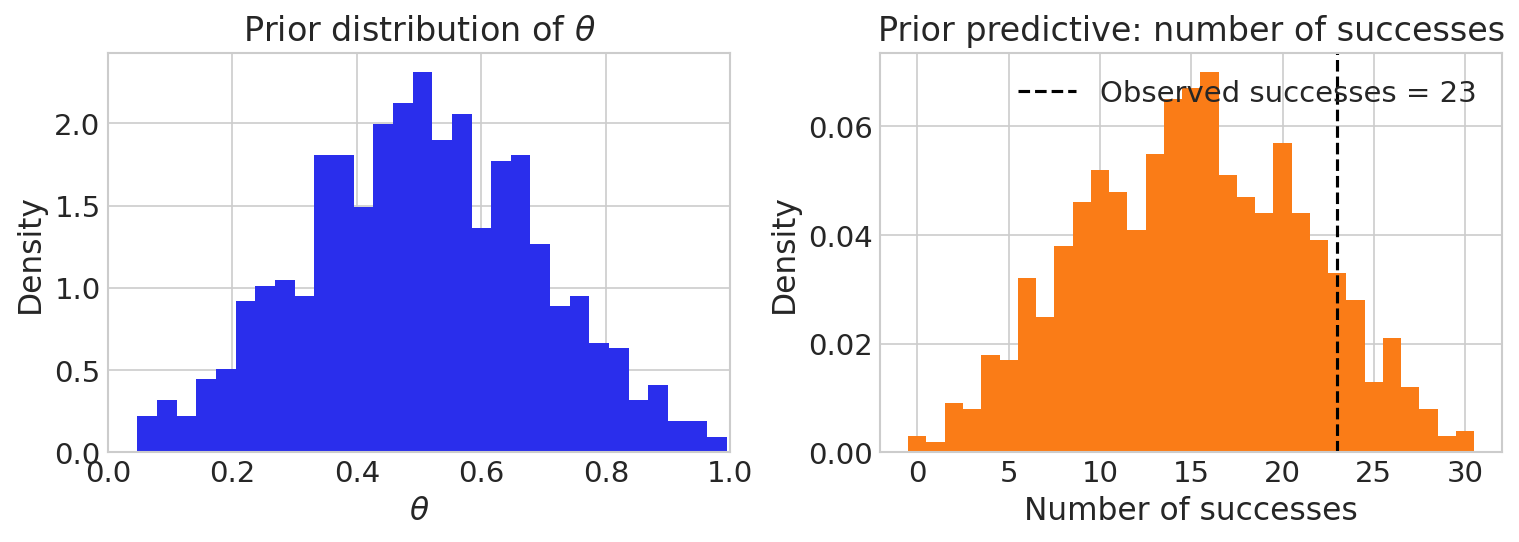

In [110]:
with nonconjugate_binomial_model:
    idata_binomial_prior = pm.sample_prior_predictive(samples=1000, random_seed=42)

prior_theta = idata_binomial_prior.prior['theta'].values.reshape(-1)
prior_y_sum = idata_binomial_prior.prior_predictive['y'].values.reshape(1000, -1).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)

axes[0].hist(prior_theta, bins=30, color='C0', density=True)
axes[0].set_xlabel(r'$\theta$')
axes[0].set_ylabel('Density')
axes[0].set_title(r'Prior distribution of $\theta$')
axes[0].set_xlim(lower, upper)

axes[1].hist(prior_y_sum, bins=range(0, sample_size + 2), color='C1', density=True, align='left')
axes[1].axvline(successes_nonbeta, color='black', linestyle='--', linewidth=1.5,
                label=f'Observed successes = {successes_nonbeta}')
axes[1].set_xlabel('Number of successes')
axes[1].set_ylabel('Density')
axes[1].set_title('Prior predictive: number of successes')
axes[1].legend(frameon=False)

plt.show()

### Sampling validity — non-conjugate binomial model
The Good NUTS run from section 4.7 used the same `nonconjugate_binomial_model`. The summary below confirms the chains mixed well and ESS is adequate.

In [111]:
az.summary(idata_nuts_good, var_names=['theta'], kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.002,0.001,1095.0,1464.0,1.01


### Posterior predictive check — non-conjugate binomial model
We pass the Good NUTS posterior through the Bernoulli likelihood to generate predicted observations. The distribution of predicted total successes should be centered near the observed count of `successes_nonbeta`.

In [115]:
with nonconjugate_binomial_model:
    pm.sample_posterior_predictive(idata_nuts_good, extend_inferencedata=True, random_seed=42)
idata_nuts_good

Sampling: [y]


Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

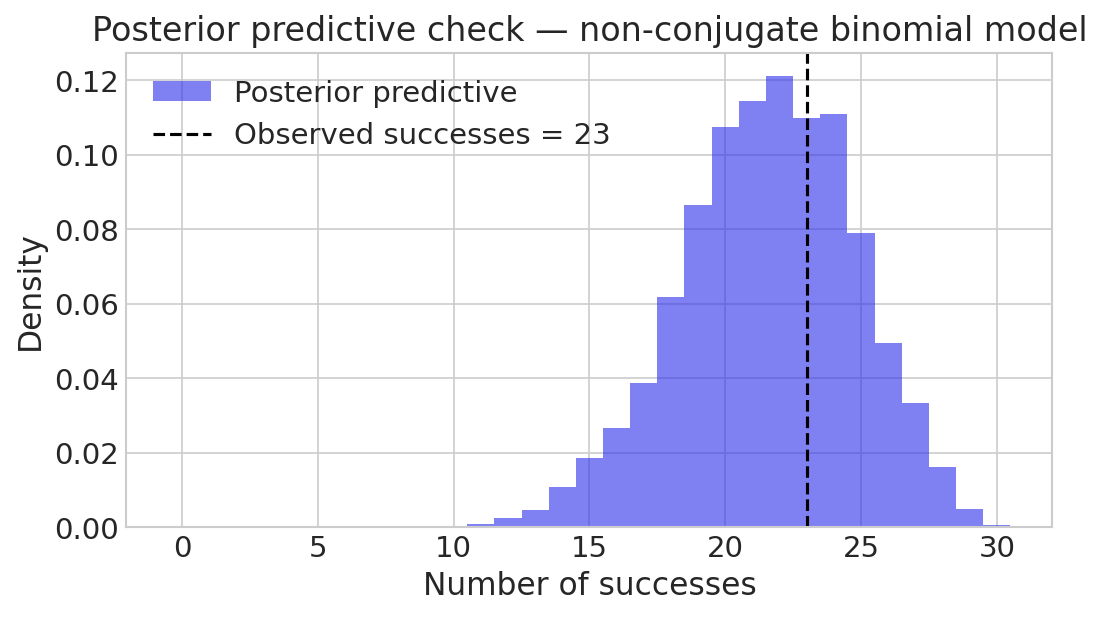

In [116]:
pp_y_sum = idata_nuts_good.posterior_predictive['y'].values.reshape(-1, sample_size).sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.hist(
    pp_y_sum,
    bins=range(0, sample_size + 2),
    density=True,
    color='C0',
    alpha=0.6,
    align='left',
    label='Posterior predictive',
)
ax.axvline(
    successes_nonbeta,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Observed successes = {successes_nonbeta}',
)
ax.set_xlabel('Number of successes')
ax.set_ylabel('Density')
ax.set_title('Posterior predictive check — non-conjugate binomial model')
ax.legend(frameon=False)
plt.show()

### Still missing in this section
- The slide-specific workflow timeline recap from slides 77-80.
- Any lecture-specific visual overlays that compare the prior, posterior, and posterior predictive blocks in one place.
